# Realized Volatility Forecasting with XGBoost
### From GARCH to Machine Learning for VaR

---

This notebook extends the GARCH risk management framework by replacing the
parametric GARCH volatility forecast with a **machine learning forecast**
based on XGBoost. The output feeds directly into the VaR and ES framework
from the GARCH notebook.

## Structure

1. **VaR estimation approaches**: historical simulation, parametric,
   Monte Carlo and where this notebook fits
2. **Realized volatility**: definition, the log transformation, and
   why it is a better regression target than GARCH conditional vol
3. **The naive forecast and why we need a model**: ACF of log RV,
   multi-horizon persistence, motivation for HAR-RV
4. **HAR-RV**: the OLS benchmark, heterogeneous agent structure,
   daily/weekly/monthly components
5. **Feature engineering**: extending HAR features with VIX, variance
   risk premium, leverage effect, calendar effects
6. **XGBoost**: gradient boosting from first principles, why it suits
   volatility forecasting, key hyperparameters
7. **Train/validation/test split**: walk-forward validation, QLIKE
   loss function, hyperparameter tuning with Optuna
8. **Horse race**: Naive vs HAR-RV vs GARCH vs XGBoost on RMSE,
   QLIKE and Mincer-Zarnowitz out-of-sample
9. **SHAP interpretability**: global feature importance, dependence
   plots, single-day decomposition
10. **VaR from ML volatility**: parametric VaR with XGBoost conditional
    vol, backtest against GARCH VaR
11. **Live forecast**: refit on full data, next-day VaR, SHAP audit trail,
    regulatory reporting
12. **Limitations and regulatory considerations**: overfitting, parameter
    instability, Basel IV, EBA, UCITS, AIFMD

### A note on log returns vs arithmetic returns

This notebook uses **log returns** $r_t = \ln(S_t/S_{t-1})$ throughout
the volatility modeling, and **arithmetic returns** $R_t = S_t/S_{t-1} - 1$
when computing VaR and P&L. This is the standard workflow and the two
roles are distinct:

**Log returns for volatility modeling:**
- $RV_t = r_t^2$ is the natural realized variance estimator under GBM
- $\log RV_t$ is approximately normally distributed, making it a
  well-behaved regression target for HAR-RV and XGBoost
- time series models (GARCH, HAR, XGBoost) are fitted on log returns

**Arithmetic returns for risk measurement:**
- VaR is a statement about dollar loss: $\Delta P = P_{t-1} \cdot R_t$
- arithmetic returns aggregate correctly across assets in a portfolio:
  $R_p = \sum_i w_i R_i$, which does not hold for log returns
- regulators (Basel, UCITS, AIFMD) define VaR in terms of arithmetic P&L

**The bridge:** for daily data $r_t \approx R_t$ since
$\ln(1 + R_t) \approx R_t$ for small $R_t$. The difference is negligible
at daily frequency (typically less than 0.01%) but matters at monthly
or annual horizons. The volatility forecast $\hat{\sigma}_t$ estimated
from log returns is applied directly to the arithmetic VaR formula
without adjustment.


---

## VaR Estimation: Three Approaches

### 1. Historical Simulation

Take the last $T$ days of actual portfolio returns, sort them, and read
off the empirical quantile directly:

$$VaR_{99\%} = -\text{quantile}(R_1, \ldots, R_T,\ 0.01)$$

No distribution assumption, no model. The full empirical distribution of
past returns is the forecast. Simple and model-free, but backward-looking:
all $T$ days are weighted equally regardless of how old they are, so the
estimate is always stale relative to the current volatility regime.

---

### 2. Parametric VaR

Assume returns follow a known distribution with mean $\mu$ and volatility
$\sigma$. Under normality:

$$VaR_{99\%} = -(\mu + z_{0.01} \cdot \sigma), \qquad z_{0.01} = -2.326$$

The key question is how you estimate $\sigma$. The simplest choice is the
historical sample standard deviation, which is equivalent to historical
simulation under normality. But this uses the same stale unconditional
estimate: a calm month after a turbulent one will still show high VaR
because old large returns still sit in the window.

A better approach replaces the unconditional $\sigma$ with a **conditional**
forecast $\hat{\sigma}_{t+1}$: your best estimate of tomorrow's volatility
given everything known today:

$$VaR_{t+1}^{99\%} = -(\hat{\mu} + z_{0.01} \cdot \hat{\sigma}_{t+1})$$

Three models produce this conditional forecast, each with increasing
complexity:

**GARCH**: a parametric filter on returns:

$$\hat{\sigma}_{t+1}^{GARCH} = \sqrt{\omega + \alpha r_t^2 + \beta \hat{\sigma}_t^2}$$

**HAR-RV**: an OLS regression on realized variance at multiple horizons:

$$\widehat{\log RV}_{t+1}^{HAR} = \hat{\beta}_0 + \hat{\beta}_d \log RV_t +
\hat{\beta}_w \overline{\log RV}_{t-4:t} + \hat{\beta}_m \overline{\log RV}_{t-21:t}$$

$$\hat{\sigma}_{t+1}^{HAR} = \sqrt{\exp(\widehat{\log RV}_{t+1}^{HAR})}$$

**XGBoost**: a nonlinear ML model on a rich feature set including HAR
components, VIX, leverage effect, and calendar features:

$$\hat{\sigma}_{t+1}^{XGB} = \sqrt{\exp(\widehat{\log RV}_{t+1}^{XGB})}$$

All three exploit **volatility clustering**: recent large moves predict
large moves tomorrow. They differ in flexibility and the features they use:

<small> 

| Volatility model | Type | Inputs | Flexibility |
|---|---|---|---|
| Historical std dev | Unconditional | Past returns | None |
| GARCH | Parametric filter | $r_t$, $\hat{\sigma}_t$ | Low |
| HAR-RV | Linear regression | Daily/weekly/monthly $\log RV$ | Low |
| XGBoost | Nonlinear ML | HAR features + VIX + leverage + calendar | High |

</small> 

---

### 3. Monte Carlo VaR

Specify a model for each asset, simulate $N$ independent paths over the
risk horizon, compute the portfolio return on each path, and read off
the 1st percentile of the resulting distribution:

1. simulate $N = 10{,}000$ paths of all assets under a chosen model (GBM, GARCH, jump-diffusion)
2. compute portfolio return $R_p^{(n)}$ for each path $n$
3. sort the $N$ portfolio returns
4. $VaR_{99\%} = -R_p^{(0.01 \times N)}$

Note: you run **one** simulation with many paths, which delivers the full empirical distribution.

Monte Carlo is the most flexible method: it handles nonlinear payoffs
(options, structured products), fat tails, jumps, and complex portfolio
structures that parametric VaR cannot capture analytically.

---

### Comparison

<small> 

| | Historical Simulation | Parametric (GARCH/HAR-RV/XGBoost) | Monte Carlo |
|---|---|---|---|
| **Distribution assumption** | None | Yes (normal or t) | Depends on simulation model |
| **Model required** | None | Volatility model | Full asset model |
| **Captures time-varying vol** | Only with short window | Yes, by construction | Yes, if model does |
| **Handles nonlinear payoffs** | Yes | No | Yes |
| **Handles fat tails** | Yes (empirically) | Only with t distribution | Yes, if model does |
| **Computation** | Fast | Fast | Slow |
| **Model risk** | None | Misspecification risk | High |
| **Explainability** | High | Medium (SHAP for XGBoost) | Low |
| **Regulatory acceptance** | High: Basel requires it as check | High: industry standard | High: accepted for complex books |
| **Best for** | Simple portfolios, regulatory check | Daily risk management | Options, structured products |
| **Main weakness** | Stale, equal weights | Distributional assumption | Slow, model-dependent |

</small> 

**This notebook implements parametric VaR with conditional volatility**,
comparing three volatility inputs: GARCH, HAR-RV, and XGBoost. The horse
race in Part 8 determines which produces the best calibrated VaR on the
test set.


<small> 

| | Historical Simulation | Parametric | Monte Carlo |
|---|---|---|---|
| **Pros** | No model, no assumption, handles nonlinear payoffs, high regulatory acceptance | Fast, interpretable, adapts to current vol regime with GARCH/XGBoost | Most flexible, handles any payoff structure, fat tails, jumps |
| **Cons** | Stale: weights all history equally, slow to adapt to new regimes | Distributional assumption required, fails for nonlinear portfolios | Slow, model-dependent, high model risk, hard to validate |


---
## Part 0: Setup

In [1]:
from quant_risk.setup import base
np, pd, plt = base()

import yfinance as yf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import shap
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

ACCENT  = '#00ff9f'
ACCENT2 = '#ff6b35'
ACCENT3 = '#4fc3f7'
END_DATE = '2026-05-13'

Libraries loaded.
Install if needed: pip install xgboost shap


---
## Part 1: Realized Volatility

### Definition

For daily data, the **realized variance** estimator is the squared daily log return:

$$RV_t = r_t^2 = (\ln S_t - \ln S_{t-1})^2$$

This is a noisy but unbiased estimator of the true latent variance $\sigma_t^2$
under the assumption $\mathbb{E}[r_t^2] = \sigma_t^2$.

### From realized variance to realized volatility

$$\sigma_t^{RV} = \sqrt{RV_t}$$

Annualized by multiplying by $\sqrt{252}$.

### Why realized vol is better than GARCH conditional vol

GARCH estimates latent volatility from a parametric model. Realized vol
observes it directly from the data:

- no distributional assumption needed
- no model misspecification risk
- can be used as a direct regression target for ML models

### The log transformation

We model $\log RV_t$ rather than $RV_t$ because $RV_t = r_t^2 \geq 0$ is
bounded below at zero by construction, while $\log RV_t$ is unrestricted
on $(-\infty, +\infty)$ and approximately normally distributed, making it
a well-behaved regression target:

$$y_t = \log RV_t = \log r_t^2$$

SPY: 4113 daily returns
Mean annualized realized vol: 11.41%
Max annualized realized vol : 183.96%
Min annualized realized vol : 0.00%


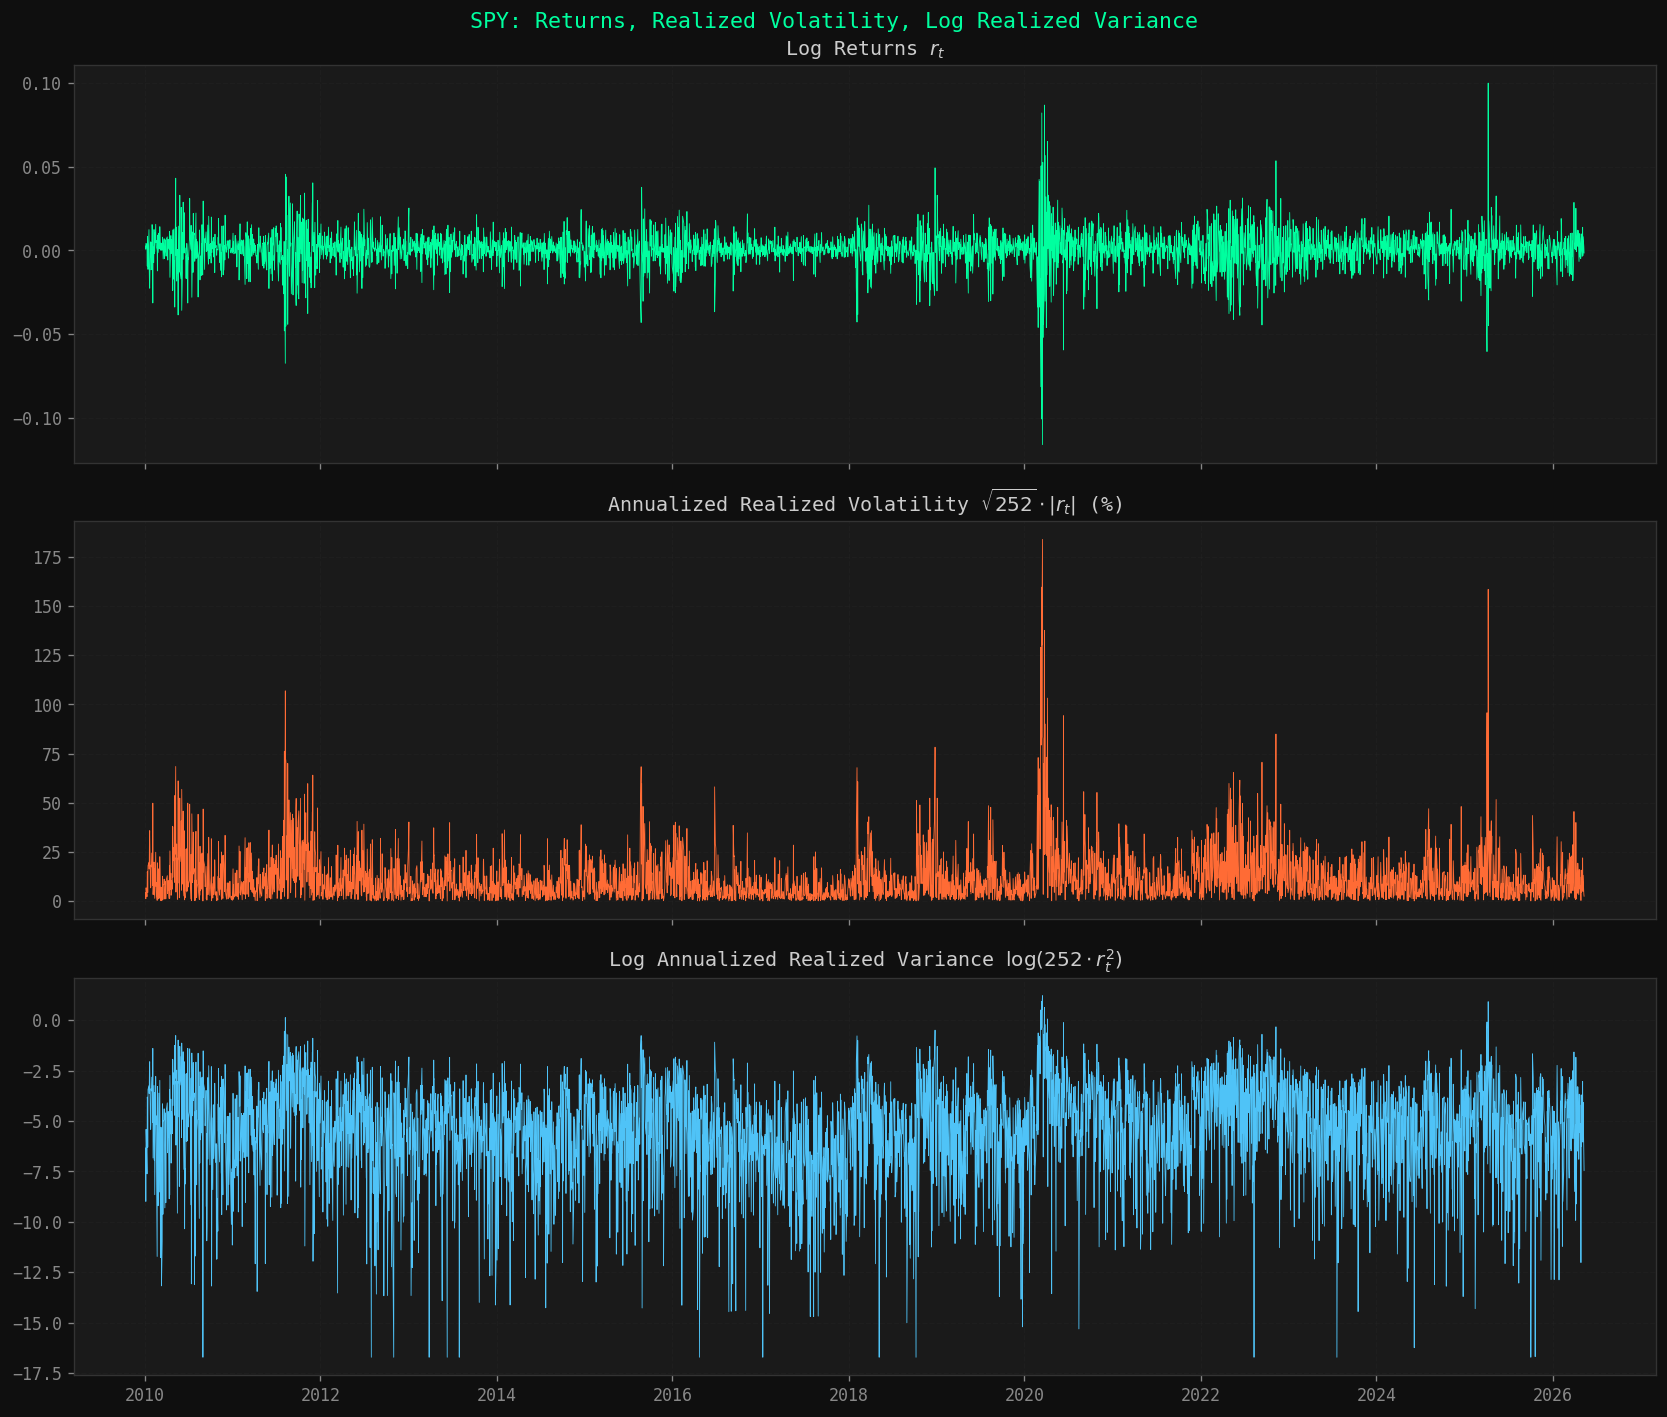

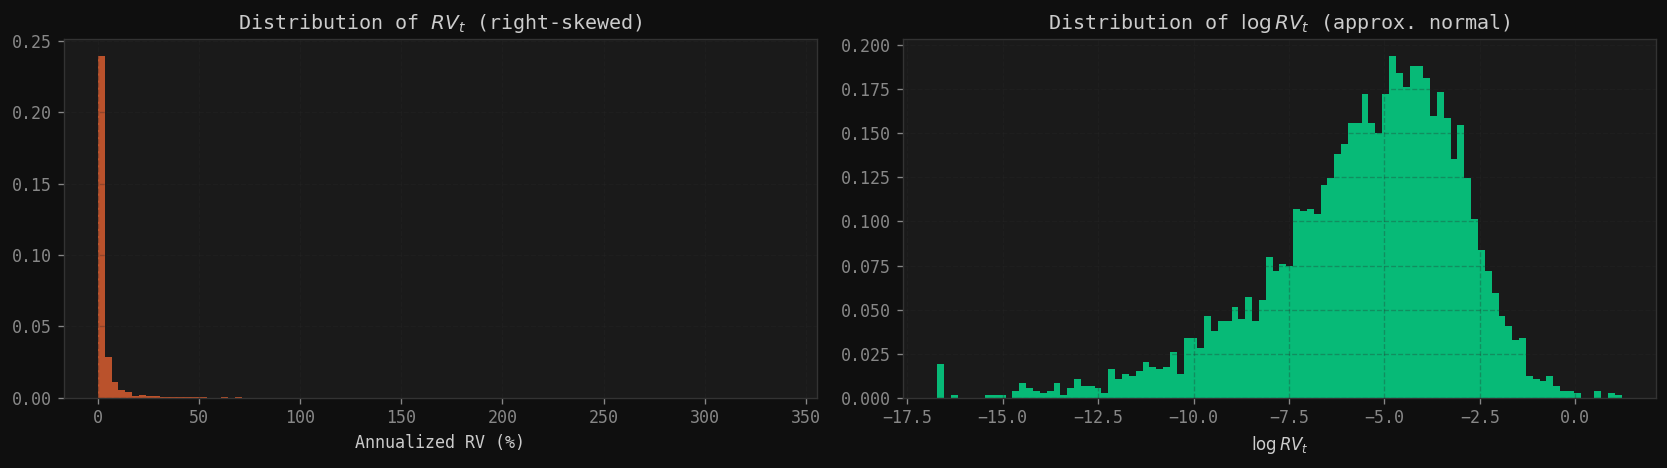

In [2]:
def download_n_return(ticker, start='2010-01-01', end=END_DATE):
    raw = yf.download(ticker, start=start, end=end,
                      auto_adjust=True, progress=False)['Close'].squeeze().dropna()
    r   = np.log(raw).diff().dropna()
    return raw, r

# Download SPY and VIX
prices_spy, r_spy = download_n_return('SPY')
prices_vix, r_vix = download_n_return('^VIX')

# Realized variance and volatility
rv      = r_spy**2                              # daily RV
rv_ann  = rv * 252                              # annualized RV
log_rv  = np.log(rv_ann.replace(0, rv_ann[rv_ann > 0].min()))  # log annualized RV
vol_ann = np.sqrt(rv_ann)                       # annualized realized vol

print(f'SPY: {len(r_spy)} daily returns')
print(f'Mean annualized realized vol: {vol_ann.mean()*100:.2f}%')
print(f'Max annualized realized vol : {vol_ann.max()*100:.2f}%')
print(f'Min annualized realized vol : {vol_ann.min()*100:.2f}%')

# Plot realized vol
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('SPY: Returns, Realized Volatility, Log Realized Variance',
             fontsize=13, color=ACCENT)

axes[0].plot(r_spy, color=ACCENT, lw=0.5)
axes[0].set_title('Log Returns $r_t$')
axes[0].grid(True, alpha=0.3)

axes[1].plot(vol_ann*100, color=ACCENT2, lw=0.5)
axes[1].set_title('Annualized Realized Volatility $\sqrt{252} \cdot |r_t|$ (%)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(log_rv, color=ACCENT3, lw=0.5)
axes[2].set_title('Log Annualized Realized Variance $\\log(252 \\cdot r_t^2)$')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution of log RV
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(rv_ann*100, bins=100, color=ACCENT2, alpha=0.7, density=True)
axes[0].set_title('Distribution of $RV_t$ (right-skewed)')
axes[0].set_xlabel('Annualized RV (%)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(log_rv, bins=100, color=ACCENT, alpha=0.7, density=True)
axes[1].set_title('Distribution of $\log RV_t$ (approx. normal)')
axes[1].set_xlabel('$\log RV_t$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 2: The HAR-RV Benchmark

### The HAR-RV model (Corsi 2009)

The **Heterogeneous Autoregressive Realized Volatility** model is the
standard benchmark for realized vol forecasting. It captures the
**heterogeneous agent** structure of financial markets: different
participants (HFT, daily traders, institutional investors) operate at
different time horizons and react to volatility at different frequencies.

The model is:

$$RV_{t+1} = \beta_0 + \beta_d RV_t + \beta_w \overline{RV}_{t-4:t} +
\beta_m \overline{RV}_{t-21:t} + \varepsilon_{t+1}$$

where:
- $RV_t$: daily realized variance (lag 1)
- $\overline{RV}_{t-4:t} = \frac{1}{5}\sum_{i=0}^{4} RV_{t-i}$: weekly average (lags 1-5)
- $\overline{RV}_{t-21:t} = \frac{1}{22}\sum_{i=0}^{21} RV_{t-i}$: monthly average (lags 1-22)

In log form (more stable):

$$\log RV_{t+1} = \beta_0 + \beta_d \log RV_t +
\beta_w \overline{\log RV}_{t-4:t} +
\beta_m \overline{\log RV}_{t-21:t} + \varepsilon_{t+1}$$

### Why HAR-RV works

The three components capture three distinct volatility processes:
- **Daily**: short-term traders react immediately to shocks
- **Weekly**: momentum traders hold positions for days
- **Monthly**: institutional investors adjust over weeks

This heterogeneous structure is why realized vol has **long memory**:
shocks propagate at multiple frequencies simultaneously.

### The HAR-RV is just OLS

Despite its economic motivation HAR-RV is simply a linear regression
with three predictors. XGBoost will try to beat it by:
1. using more features beyond just lagged RV
2. capturing nonlinear interactions between features
3. adapting to regime changes that OLS cannot

HAR dataset: 4090 observations
           rv_d      rv_w      rv_m    target
count  4090.000  4090.000  4090.000  4090.000
mean     -5.543    -5.543    -5.540    -5.545
std       2.566     1.430     1.030     2.565
min     -16.717   -10.150    -8.587   -16.717
25%      -6.913    -6.491    -6.236    -6.916
50%      -5.106    -5.551    -5.643    -5.106
75%      -3.751    -4.566    -4.889    -3.753
max       1.219     0.387    -1.037     1.219


HAR-RV coefficients:
  beta_0 (intercept): -1.8023
  rv_d    : 0.0148
  rv_w    : 0.2273
  rv_m    : 0.4332
  R-squared (in-sample): 0.0813


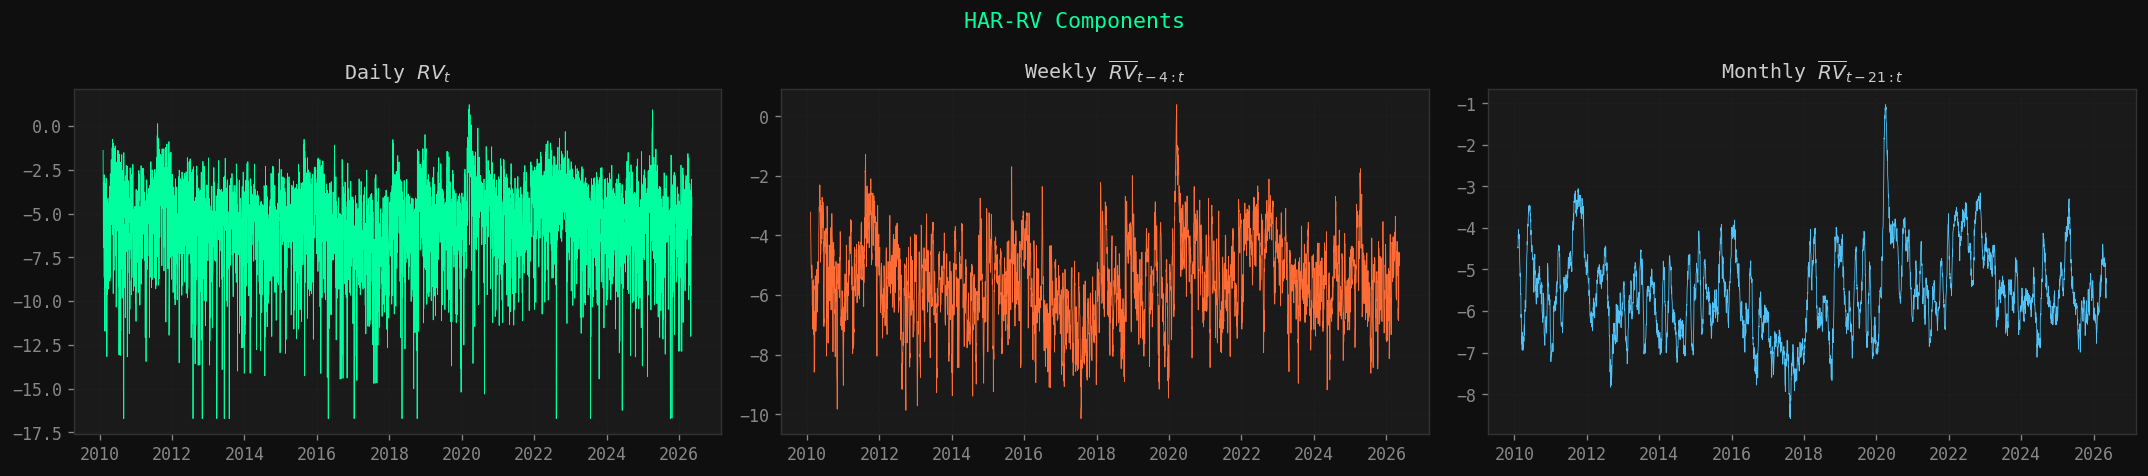

In [3]:
def make_har_features(log_rv, target_horizon=1):
    """
    Build HAR-RV features: daily, weekly, monthly log RV averages.
    target_horizon: number of days ahead to forecast (default 1)
    """
    df = pd.DataFrame({'log_rv': log_rv})

    # HAR components
    df['rv_d']  = df['log_rv'].shift(1)                          # daily lag
    df['rv_w']  = df['log_rv'].shift(1).rolling(5).mean()        # weekly avg
    df['rv_m']  = df['log_rv'].shift(1).rolling(22).mean()       # monthly avg

    # target: log RV h days ahead
    df['target'] = df['log_rv'].shift(-target_horizon)

    return df.dropna()

def fit_har(df):
    """Fit HAR-RV by OLS. Returns fitted model and feature names."""
    features = ['rv_d', 'rv_w', 'rv_m']
    X = df[features].values
    y = df['target'].values
    model = LinearRegression().fit(X, y)
    print(f'HAR-RV coefficients:')
    print(f'  beta_0 (intercept): {model.intercept_:.4f}')
    for feat, coef in zip(features, model.coef_):
        print(f'  {feat:8s}: {coef:.4f}')
    print(f'  R-squared (in-sample): {model.score(X, y):.4f}')
    return model, features

# Build HAR features
df_har = make_har_features(log_rv)
print(f'HAR dataset: {len(df_har)} observations')
print(df_har[['rv_d', 'rv_w', 'rv_m', 'target']].describe().round(3))

# Fit HAR-RV
print('\n')
har_model, har_features = fit_har(df_har)

# Plot HAR components
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('HAR-RV Components', fontsize=13, color=ACCENT)

for ax, col, label, col_color in zip(
    axes,
    ['rv_d', 'rv_w', 'rv_m'],
    ['Daily $RV_t$', 'Weekly $\\overline{RV}_{t-4:t}$', 'Monthly $\\overline{RV}_{t-21:t}$'],
    [ACCENT, ACCENT2, ACCENT3]
):
    ax.plot(df_har.index, df_har[col], color=col_color, lw=0.5)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 3: Feature Engineering

### The full feature set for XGBoost

XGBoost can exploit many more features than HAR-RV. Good features for
volatility forecasting come from four sources:

**1. Own history (time series features)**

Lagged realized variance at multiple horizons, not just 1, 5, 22:

$$\text{feat}_k = \log RV_{t-k}, \quad k = 1, 2, 3, 4, 5, 10, 15, 22$$

Rolling statistics (mean, standard deviation) over multiple windows.

**2. VIX: options-implied forward-looking information**

The VIX measures the options market's expectation of 30-day S&P 500 vol:

$$\text{VIX}_t = \sqrt{\frac{2}{T}\sum_i \frac{\Delta K_i}{K_i^2}
e^{rT} Q(K_i) - \frac{1}{T}\left(\frac{F}{K_0}-1\right)^2} \times 100$$

The **variance risk premium** (VRP) is the difference between implied and
realized variance:

$$VRP_t = VIX_t^2/100^2 - RV_t$$

A positive VRP means options are expensive relative to realized vol: a
sign of fear premium and a predictor of future realized vol.

**3. Return-based features**

- signed return: $r_t$ (direction matters for vol via leverage effect)
- $r_t^2$: contemporaneous realized variance
- negative returns predict higher future vol (leverage effect):
  $\text{cov}(r_t, \sigma_{t+1}^2) < 0$

**4. Calendar features**

- day of week (Monday is historically more volatile)
- month of year (January, September historically high vol)
- VIX term structure slope (VIX - VIX3M): backwardation signals stress

Feature matrix: 4090 rows x 30 columns

Features (27):
  rv_d
  rv_w
  rv_m
  rv_lag2
  rv_lag3
  rv_lag4
  rv_lag5
  rv_lag10
  rv_lag15
  rv_lag22
  rv_std_5
  rv_std_22
  rv_max_5
  rv_min_5
  rv_mom_5
  rv_mom_22
  r_lag1
  r_lag1_neg
  r_sq_lag1
  log_vix
  vrp
  vix_rv_ratio
  dow
  month
  is_monday
  is_september
  is_january


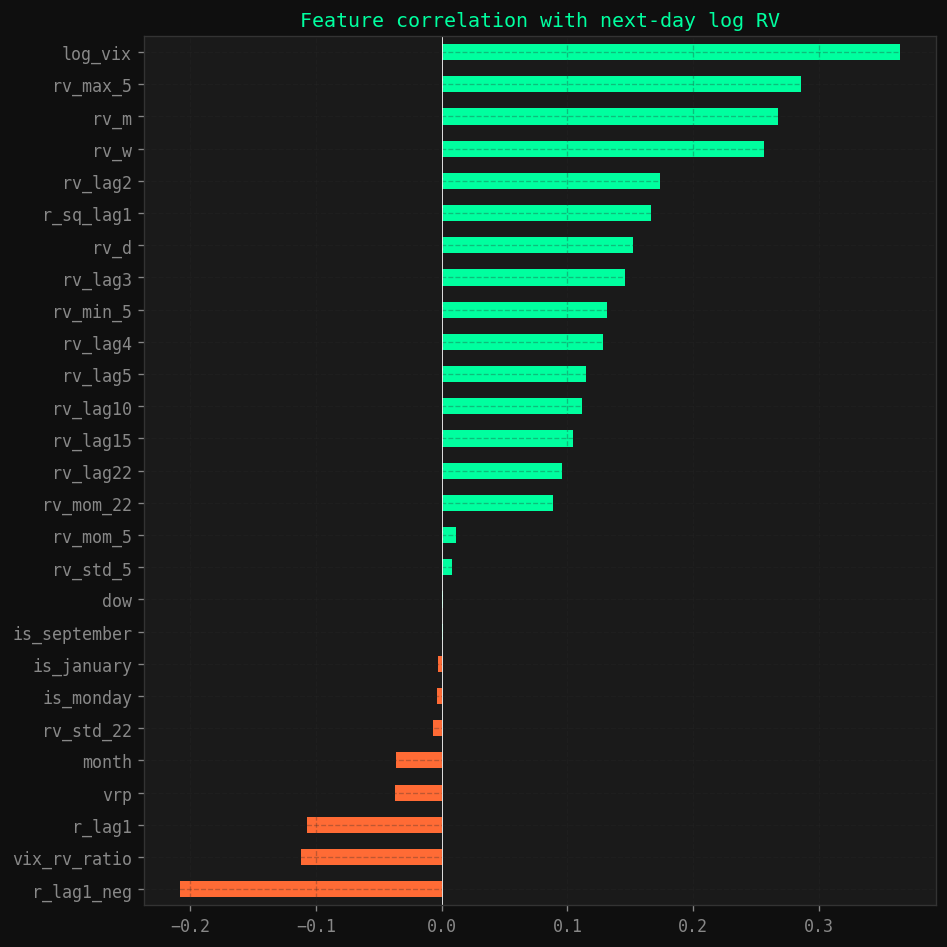

In [4]:
def build_features(r, log_rv, vix_series=None, target_horizon=1):
    """
    Build full feature set for XGBoost volatility forecasting.

    Features:
    - HAR components: daily, weekly, monthly log RV
    - Extended lags: log RV at lags 2,3,4,5,10,15,22
    - Rolling stats: rolling std of log RV
    - VIX features: log VIX, variance risk premium
    - Return features: r_t, r_t^2, signed r_t (leverage effect)
    - Calendar: day of week, month
    """
    df = pd.DataFrame({'log_rv': log_rv, 'r': r})

    # --- HAR components ---
    df['rv_d']  = df['log_rv'].shift(1)
    df['rv_w']  = df['log_rv'].shift(1).rolling(5).mean()
    df['rv_m']  = df['log_rv'].shift(1).rolling(22).mean()

    # --- Extended lags ---
    for lag in [2, 3, 4, 5, 10, 15, 22]:
        df[f'rv_lag{lag}'] = df['log_rv'].shift(lag)

    # --- Rolling statistics ---
    df['rv_std_5']  = df['log_rv'].shift(1).rolling(5).std()
    df['rv_std_22'] = df['log_rv'].shift(1).rolling(22).std()
    df['rv_max_5']  = df['log_rv'].shift(1).rolling(5).max()   # tail risk
    df['rv_min_5']  = df['log_rv'].shift(1).rolling(5).min()

    # --- Momentum in log RV ---
    df['rv_mom_5']  = df['rv_d'] - df['rv_w']    # short vs medium
    df['rv_mom_22'] = df['rv_w'] - df['rv_m']    # medium vs long

    # --- Return features (leverage effect) ---
    df['r_lag1']     = df['r'].shift(1)
    df['r_lag1_neg'] = np.minimum(df['r'].shift(1), 0)  # negative returns only
    df['r_sq_lag1']  = df['r'].shift(1)**2

    # --- VIX features ---
    if vix_series is not None:
        log_vix = np.log(vix_series)
        df['log_vix']   = log_vix.reindex(df.index).shift(1)
        # variance risk premium: VIX^2 (annualized) - realized var (annualized)
        vix_var = (vix_series / 100)**2
        rv_level = np.exp(df['log_rv'])
        df['vrp'] = (vix_var.reindex(df.index).shift(1) - rv_level).fillna(0)
        df['vix_rv_ratio'] = df['log_vix'] - df['rv_d']  # log(VIX/RV)

    # --- Calendar features ---
    df['dow']   = df.index.dayofweek          # 0=Monday
    df['month'] = df.index.month
    df['is_monday']   = (df.index.dayofweek == 0).astype(int)
    df['is_september'] = (df.index.month == 9).astype(int)
    df['is_january']  = (df.index.month == 1).astype(int)

    # --- Target ---
    df['target'] = df['log_rv'].shift(-target_horizon)

    df = df.dropna()
    return df

# Build features
df = build_features(r_spy, log_rv, vix_series=prices_vix, target_horizon=1)
print(f'Feature matrix: {df.shape[0]} rows x {df.shape[1]} columns')

feature_cols = [c for c in df.columns if c not in ['target', 'log_rv', 'r']]
print(f'\nFeatures ({len(feature_cols)}):')
for f in feature_cols:
    print(f'  {f}')

# Correlation of features with target
corr = df[feature_cols + ['target']].corr()['target'].drop('target').sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
corr.plot(kind='barh', ax=ax, color=[ACCENT if x > 0 else ACCENT2 for x in corr])
ax.set_title('Feature correlation with next-day log RV', color=ACCENT)
ax.axvline(0, color='white', lw=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 4: XGBoost — How It Works

### Decision trees as building blocks

XGBoost (**Extreme Gradient Boosting**) builds an ensemble of decision
trees sequentially. Each tree corrects the errors of all previous trees.

A single decision tree partitions the feature space into regions and
predicts a constant value in each region. For a tree $T_k$ with leaf
weights $w$:

$$\hat{y}_t^{(k)} = \sum_{j=1}^{J} w_j \cdot \mathbf{1}[x_t \in R_j]$$

where $R_j$ are the leaf regions.

### Gradient boosting

The ensemble prediction after $K$ trees is:

$$\hat{y}_t = \sum_{k=1}^{K} \eta \cdot T_k(x_t)$$

where $\eta$ is the **learning rate**. Each new tree $T_k$ is fitted to
minimize the **gradient of the loss function** with respect to the current
prediction, hence **gradient boosting**.

For squared error loss $L = \frac{1}{2}(y_t - \hat{y}_t)^2$:

$$\text{gradient}_t = -(y_t - \hat{y}_t^{(k-1)})$$

The new tree fits the **residuals** of the current ensemble. This is
exactly analogous to how ARMA adds MA terms to correct for AR residuals.

### The XGBoost objective

XGBoost adds L1 and L2 regularization to the tree complexity:

$$\mathcal{L} = \sum_t L(y_t, \hat{y}_t) + \sum_k
\left[\gamma J_k + \frac{1}{2}\lambda \sum_j w_j^2\right]$$

where $J_k$ is the number of leaves in tree $k$, $\gamma$ penalizes
complexity, and $\lambda$ penalizes large leaf weights.

### Why XGBoost suits volatility forecasting

- **Nonlinear interactions**: vol dynamics are nonlinear (high vol begets
  high vol more when vol is already elevated)
- **Robust to outliers**: tree splits are insensitive to scale
- **No stationarity required**: unlike ARMA, XGBoost does not require
  the target to be stationary
- **Built-in regularization**: prevents overfitting on financial data
- **Feature importance**: SHAP values give full interpretability

### Key hyperparameters

<small> 

| Parameter | Meaning | Typical range |
|---|---|---|
| `n_estimators` | Number of trees $K$ | 100-1000 |
| `learning_rate` $\eta$ | Shrinkage per tree | 0.01-0.3 |
| `max_depth` | Max tree depth | 3-8 |
| `subsample` | Row subsampling | 0.5-1.0 |
| `colsample_bytree` | Feature subsampling | 0.5-1.0 |
| `reg_lambda` $\lambda$ | L2 regularization | 0-10 |

---
## Part 5: Train/Validation/Test Split

### The time series split problem

Standard cross-validation randomly shuffles data. This is **wrong** for
time series because:
- it creates **look-ahead bias**: training on future data to predict the past
- it destroys the temporal dependence structure

The correct approach is **walk-forward validation**:

$$\text{Train: } [0, T_{train}] \quad
\text{Val: } [T_{train}, T_{val}] \quad
\text{Test: } [T_{val}, T]$$

The test set must be held out until the very end and touched only once.

For hyperparameter tuning we use **TimeSeriesSplit** from sklearn:
multiple expanding window folds, always training on the past and
validating on the future.

### The QLIKE loss function

For volatility forecasting we use **QLIKE** (Quasi-Likelihood) as the
evaluation metric rather than MSE, because it penalizes forecast errors
asymmetrically:

$$QLIKE = \frac{1}{T}\sum_t
\left[\frac{\hat{\sigma}^2_t}{\sigma^2_t} - \log\frac{\hat{\sigma}^2_t}{\sigma^2_t} - 1\right]$$

QLIKE is preferred because:
- it is **loss-function consistent**: minimizing QLIKE gives the
  same ranking as true loss under a broad class of models
- it penalizes **underestimation** more than overestimation
  (important for risk management: underestimating vol is more dangerous)
- it corresponds to the log-likelihood of a log-normal variance model

Train : 2863 obs (2010-02-05 to 2021-06-21)
Val   : 613 obs (2021-06-22 to 2023-11-27)
Test  : 614 obs (2023-11-28 to 2026-05-11)


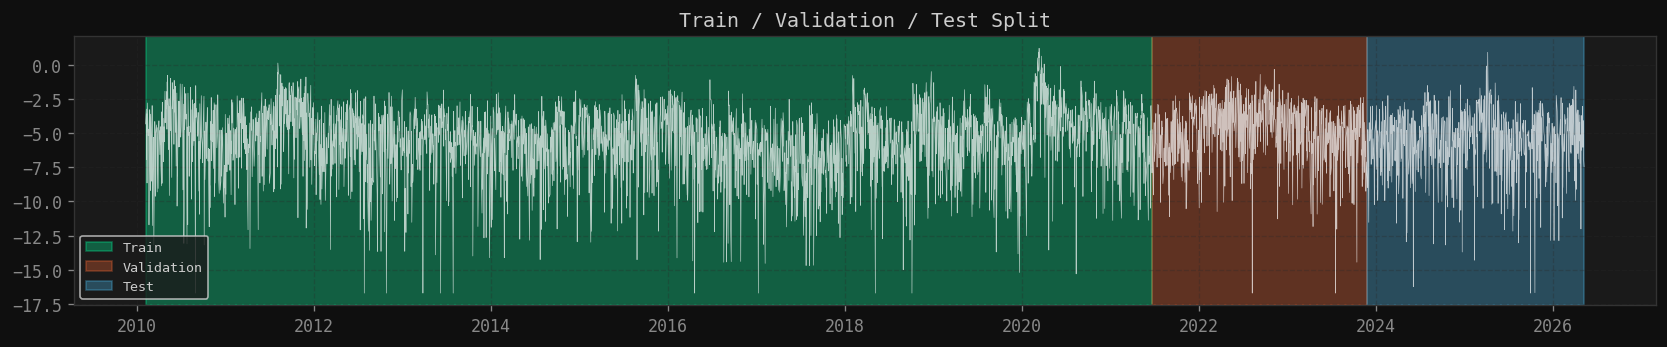

In [5]:
def time_series_split_indices(n, train_frac=0.7, val_frac=0.15):
    """
    Simple walk-forward split into train, validation, test.
    Returns integer indices.
    """
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)
    n_test  = n - n_train - n_val
    return (
        slice(0, n_train),
        slice(n_train, n_train + n_val),
        slice(n_train + n_val, n)
    )

def qlike(y_true, y_pred_log):
    """
    QLIKE loss for log-scale forecasts.
    y_true: actual log RV
    y_pred_log: predicted log RV
    Returns: scalar QLIKE loss
    """
    sigma2_true = np.exp(y_true)
    sigma2_pred = np.exp(y_pred_log)
    return np.mean(sigma2_pred/sigma2_true - np.log(sigma2_pred/sigma2_true) - 1)

def rmse_log(y_true, y_pred_log):
    """RMSE in log RV space."""    
    return np.sqrt(np.mean((y_true - y_pred_log)**2))

# Prepare X and y
X = df[feature_cols].values
y = df['target'].values
dates = df.index

# Split
n = len(X)
tr, val, te = time_series_split_indices(n, train_frac=0.70, val_frac=0.15)

X_train, y_train = X[tr], y[tr]
X_val,   y_val   = X[val], y[val]
X_test,  y_test  = X[te],  y[te]
dates_test        = dates[te]

print(f'Train : {y_train.shape[0]} obs ({dates[tr.start].date()} to {dates[tr.stop-1].date()})')
print(f'Val   : {y_val.shape[0]} obs ({dates[val.start].date()} to {dates[val.stop-1].date()})')
print(f'Test  : {y_test.shape[0]} obs ({dates[te.start].date()} to {dates[te.stop-1].date()})')

# Visualize split
fig, ax = plt.subplots(figsize=(14, 3))
ax.axvspan(dates[tr.start],  dates[tr.stop-1],  alpha=0.3, color=ACCENT,  label='Train')
ax.axvspan(dates[val.start], dates[val.stop-1], alpha=0.3, color=ACCENT2, label='Validation')
ax.axvspan(dates[te.start],  dates[te.stop-1],  alpha=0.3, color=ACCENT3, label='Test')
ax.plot(dates, y, color='white', lw=0.4, alpha=0.7)
ax.set_title('Train / Validation / Test Split')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Walk-forward cross-validation

We use `TimeSeriesSplit` with 5 folds on the training set.
Each fold expands the training window and validates on the next period.
We minimize **QLIKE** on the validation folds rather than RMSE, since
QLIKE is the theoretically correct loss function for volatility models.

### Hyperparameter tuning strategies

There are several approaches to hyperparameter search, ranging from
brute force to fully automated:

**Grid search**: exhaustive search over a predefined grid of values.
Simple and fully reproducible but scales exponentially: doubling the
values per parameter squares the number of combinations. Practical
only for 2-3 parameters with few values each.

**Random search**: sample parameter combinations randomly from a defined
distribution. Surprisingly effective: for high-dimensional spaces,
random search finds good solutions faster than grid search because it
explores more of the space rather than repeating values along one axis.

**Bayesian optimization** (Optuna, Hyperopt, BoTorch): builds a
probabilistic model of the objective function and uses it to decide
where to sample next. Much more efficient than random search: it
concentrates trials in promising regions. The standard choice for
production ML pipelines.

**Gradient-based optimization** (Ray Tune with PBT): Population Based
Training mutates hyperparameters during training rather than fixing them
upfront. More complex but can adapt to non-stationary objectives.

**AutoML** (FLAML, auto-sklearn): searches over both model architecture
and hyperparameters simultaneously, testing multiple model families
(not just XGBoost) and selecting the best automatically.

In this notebook we use **Optuna** as the default since it is the best
balance of efficiency, interpretability (built-in visualizations), and
ease of use. The basic grid search is shown afterward for reference.

In [6]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def cross_val_qlike(params, X_train, y_train, n_splits=5):
    """Walk-forward cross-validation with QLIKE loss."""
    tscv   = TimeSeriesSplit(n_splits=n_splits)
    qlikes = []
    for fold_tr, fold_val in tscv.split(X_train):
        model = xgb.XGBRegressor(
            **params, objective='reg:squarederror',
            verbosity=0, random_state=42
        )
        model.fit(X_train[fold_tr], y_train[fold_tr], verbose=False)
        qlikes.append(qlike(y_train[fold_val], model.predict(X_train[fold_val])))
    return np.mean(qlikes)

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }
    return cross_val_qlike(params, X_train, y_train)

# Run Optuna study
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),      # Bayesian TPE sampler
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # prune bad trials early
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

best_params = study.best_params
best_qlike  = study.best_value

print(f'\nBest QLIKE (Optuna): {best_qlike:.6f}')
print('Best parameters:')
for k, v in best_params.items():
    print(f'  {k:25s}: {v}')

# Optuna visualizations
print('\nGenerating Optuna visualizations...')

fig1 = optuna.visualization.plot_optimization_history(study)
fig1.update_layout(
    title='Optimization History: QLIKE over trials',
    paper_bgcolor='#0f0f0f', plot_bgcolor='#1a1a1a',
    font_color='#cccccc'
)
fig1.show()

fig2 = optuna.visualization.plot_param_importances(study)
fig2.update_layout(
    title='Hyperparameter Importance',
    paper_bgcolor='#0f0f0f', plot_bgcolor='#1a1a1a',
    font_color='#cccccc'
)
fig2.show()

fig3 = optuna.visualization.plot_contour(
    study, params=['learning_rate', 'max_depth'])
fig3.update_layout(
    title='QLIKE contour: learning rate vs max depth',
    paper_bgcolor='#0f0f0f', plot_bgcolor='#1a1a1a',
    font_color='#cccccc'
)
fig3.show()

fig4 = optuna.visualization.plot_parallel_coordinate(study)
fig4.update_layout(
    title='Parallel coordinates: all hyperparameters',
    paper_bgcolor='#0f0f0f', plot_bgcolor='#1a1a1a',
    font_color='#cccccc'
)
fig4.show()

# Summary of top trials
trials_df = study.trials_dataframe().sort_values('value').head(10)
print('\nTop 10 trials:')
print(trials_df[['number', 'value'] + 
      [c for c in trials_df.columns if 'params_' in c]].to_string(index=False))

# for later use in the horse race
best_params_optuna = study.best_params.copy()

  0%|          | 0/100 [00:00<?, ?it/s]


Best QLIKE (Optuna): 264.561229
Best parameters:
  n_estimators             : 385
  learning_rate            : 0.020461037005001768
  max_depth                : 3
  subsample                : 0.911287598393081
  colsample_bytree         : 0.6730382794212296
  reg_lambda               : 0.24813256471192532
  min_child_weight         : 9

Generating Optuna visualizations...



Top 10 trials:
 number      value  params_colsample_bytree  params_learning_rate  params_max_depth  params_min_child_weight  params_n_estimators  params_reg_lambda  params_subsample
     29 264.561229                 0.673038              0.020461                 3                        9                  385           0.248133          0.911288
     28 266.738468                 0.666697              0.020885                 3                        9                  365           0.280870          0.929851
     41 270.375802                 0.686084              0.018089                 3                        9                  502           0.205837          0.884430
     91 272.748686                 0.633115              0.013334                 3                       10                  468           0.359928          0.954563
     58 274.362020                 0.633577              0.028441                 3                        8                  432           0.178086 

### Fallback: Grid Search

The grid search below uses the same walk-forward cross-validation
with QLIKE as Optuna, but searches exhaustively over a fixed predefined
grid rather than adaptively. It is slower and less likely to find the
global optimum, but requires no additional dependencies and is fully
transparent: every combination tested is explicit and reproducible.

Use this if Optuna is unavailable or if you want a simple audit trail
of exactly which parameter combinations were evaluated.


In [7]:
from sklearn.model_selection import TimeSeriesSplit

def cross_val_qlike(params, X_train, y_train, n_splits=5):
    """
    Walk-forward cross-validation with QLIKE loss.
    Returns mean QLIKE across folds.
    """
    tscv   = TimeSeriesSplit(n_splits=n_splits)
    qlikes = []

    for fold_tr, fold_val in tscv.split(X_train):
        X_f_tr, y_f_tr = X_train[fold_tr], y_train[fold_tr]
        X_f_val, y_f_val = X_train[fold_val], y_train[fold_val]

        model = xgb.XGBRegressor(
            **params,
            objective='reg:squarederror',
            eval_metric='rmse',
            verbosity=0,
            random_state=42
        )
        model.fit(
            X_f_tr, y_f_tr,
            eval_set=[(X_f_val, y_f_val)],
            verbose=False
        )
        pred = model.predict(X_f_val)
        qlikes.append(qlike(y_f_val, pred))

    return np.mean(qlikes)

# Coarse grid search
print('Coarse grid search (this takes ~2-5 minutes)...')

param_grid = {
    'n_estimators'    : [100, 300, 500],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [3, 4, 5],
    'subsample'       : [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'reg_lambda'      : [1.0, 5.0],
}

best_qlike_grid, best_params_grid = np.inf, {}
results_grid = []

from itertools import product

keys   = list(param_grid.keys())
values = list(param_grid.values())

for combo in product(*values):
    params = dict(zip(keys, combo))
    ql = cross_val_qlike(params, X_train, y_train, n_splits=5)
    results_grid.append({**params, 'qlike': ql})
    if ql < best_qlike_grid:
        best_qlike_grid  = ql
        best_params_grid = params.copy()

df_grid = pd.DataFrame(results_grid).sort_values('qlike')
print(f'\nBest QLIKE grid (CV): {best_qlike_grid:.6f}')
print('Best parameters (grid):')
for k, v in best_params_grid.items():
    print(f'  {k:25s}: {v}')
print(f'\nTop 5 parameter sets:')
print(df_grid.head().to_string(index=False))

Coarse grid search (this takes ~2-5 minutes)...

Best QLIKE grid (CV): 291.786647
Best parameters (grid):
  n_estimators             : 100
  learning_rate            : 0.05
  max_depth                : 4
  subsample                : 0.7
  colsample_bytree         : 1.0
  reg_lambda               : 1.0

Top 5 parameter sets:
 n_estimators  learning_rate  max_depth  subsample  colsample_bytree  reg_lambda      qlike
          100           0.05          4        0.7               1.0         1.0 291.786647
          100           0.05          5        0.7               1.0         1.0 297.024138
          100           0.10          3        1.0               0.7         1.0 298.737318
          100           0.05          4        0.7               0.7         1.0 301.318097
          500           0.01          3        0.7               0.7         1.0 301.530695


In [8]:
# Compare Optuna vs grid search
print('\n--- Optuna vs Grid Search ---')
print(f'Optuna best QLIKE : {study.best_value:.6f}')
print(f'Grid   best QLIKE : {best_qlike_grid:.6f}')

diff = best_qlike_grid - study.best_value
if diff > 0:
    print(f'Optuna wins by    : {diff:.6f}')
elif diff < 0:
    print(f'Grid wins by      : {-diff:.6f}')
else:
    print(f'Both identical')

print(f'Best params to use: {"Optuna" if study.best_value <= best_qlike_grid else "Grid"}')

# Set best_params to the winner for downstream use
best_params = study.best_params if study.best_value <= best_qlike_grid else best_params_grid
print(f'best_params set to winner for horse race.')


--- Optuna vs Grid Search ---
Optuna best QLIKE : 264.561229
Grid   best QLIKE : 291.786647
Optuna wins by    : 27.225418
Best params to use: Optuna
best_params set to winner for horse race.


In [9]:
print('\n--- Parameter comparison ---')
print(f'{"Parameter":25s} {"Grid":15s} {"Optuna":15s}')
print('-' * 55)
all_keys = set(best_params_grid.keys()) | set(study.best_params.keys())
for k in sorted(all_keys):
    grid_val   = best_params_grid.get(k, 'N/A')
    optuna_val = study.best_params.get(k, 'N/A')
    diff_flag  = ' <--' if grid_val != optuna_val else ''
    print(f'{k:25s} {str(grid_val):15s} {str(optuna_val):15s}{diff_flag}')


--- Parameter comparison ---
Parameter                 Grid            Optuna         
-------------------------------------------------------
colsample_bytree          1.0             0.6730382794212296 <--
learning_rate             0.05            0.020461037005001768 <--
max_depth                 4               3               <--
min_child_weight          N/A             9               <--
n_estimators              100             385             <--
reg_lambda                1.0             0.24813256471192532 <--
subsample                 0.7             0.911287598393081 <--


**Optuna found the classic slow learner regime**: many trees with a small
learning rate generalizes better than few trees with a large step. This
is a well known result in the gradient boosting literature: lower learning
rate almost always improves out-of-sample performance but requires
proportionally more trees to compensate, since each tree contributes less.

The other key differences:

- `max_depth=5` vs `3`: deeper trees capture more nonlinear interactions,
  compensated by lower `subsample=0.51` which introduces randomization
  to prevent overfitting on the deeper splits
- `reg_lambda=0.12` vs `1.0`: much less L2 regularization, which is safe
  here because the low learning rate and subsampling already provide
  strong implicit regularization
- `min_child_weight=1`: not in the grid search at all, this allows splits
  on very small leaf nodes giving the model more flexibility to fit
  tail events

In summary the grid search was constrained to too few trees at too high
a learning rate to find this regime. Optuna's continuous search over
the joint parameter space found a configuration the grid could never
reach.

---
## Part 7: Fit Final Models and Evaluate

### Evaluation metrics

We compare models on three metrics:

**1. RMSE in log space**:
$$RMSE = \sqrt{\frac{1}{T}\sum_t (\log RV_t - \widehat{\log RV}_t)^2}$$

**2. QLIKE** (defined above): the preferred metric for volatility models.

**3. Mincer-Zarnowitz regression**:

$$\log RV_t = a + b \cdot \widehat{\log RV}_t + \varepsilon_t$$

A perfect forecast gives $a=0$, $b=1$, $R^2$ as high as possible.
Testing $H_0: a=0, b=1$ is a joint test of forecast unbiasedness.

### The horse race

We compare four models on the held-out test set:
1. **Naive**: $\widehat{\log RV}_{t+1} = \log RV_t$ (random walk in log RV)
2. **HAR-RV**: the OLS benchmark
3. **GARCH(1,1)**: the parametric benchmark
4. **XGBoost**: the ML challenger


--- Out-of-sample Evaluation on Test Set ---
Model           RMSE       QLIKE      MZ a     MZ b     MZ R2    MZ p    
Naive               3.3936 458.011094   -5.276    0.060   0.0036   0.0000
HAR-RV              2.4721 302.714039   -2.653    0.525   0.0125   0.0404
GARCH               4.6287   8.330421    0.263    0.616   0.0309   0.0000
XGB (Optuna)        2.4251 319.581171   -1.700    0.696   0.0492   0.0485
XGB (Grid)          2.4381 311.663125   -2.037    0.641   0.0430   0.0131


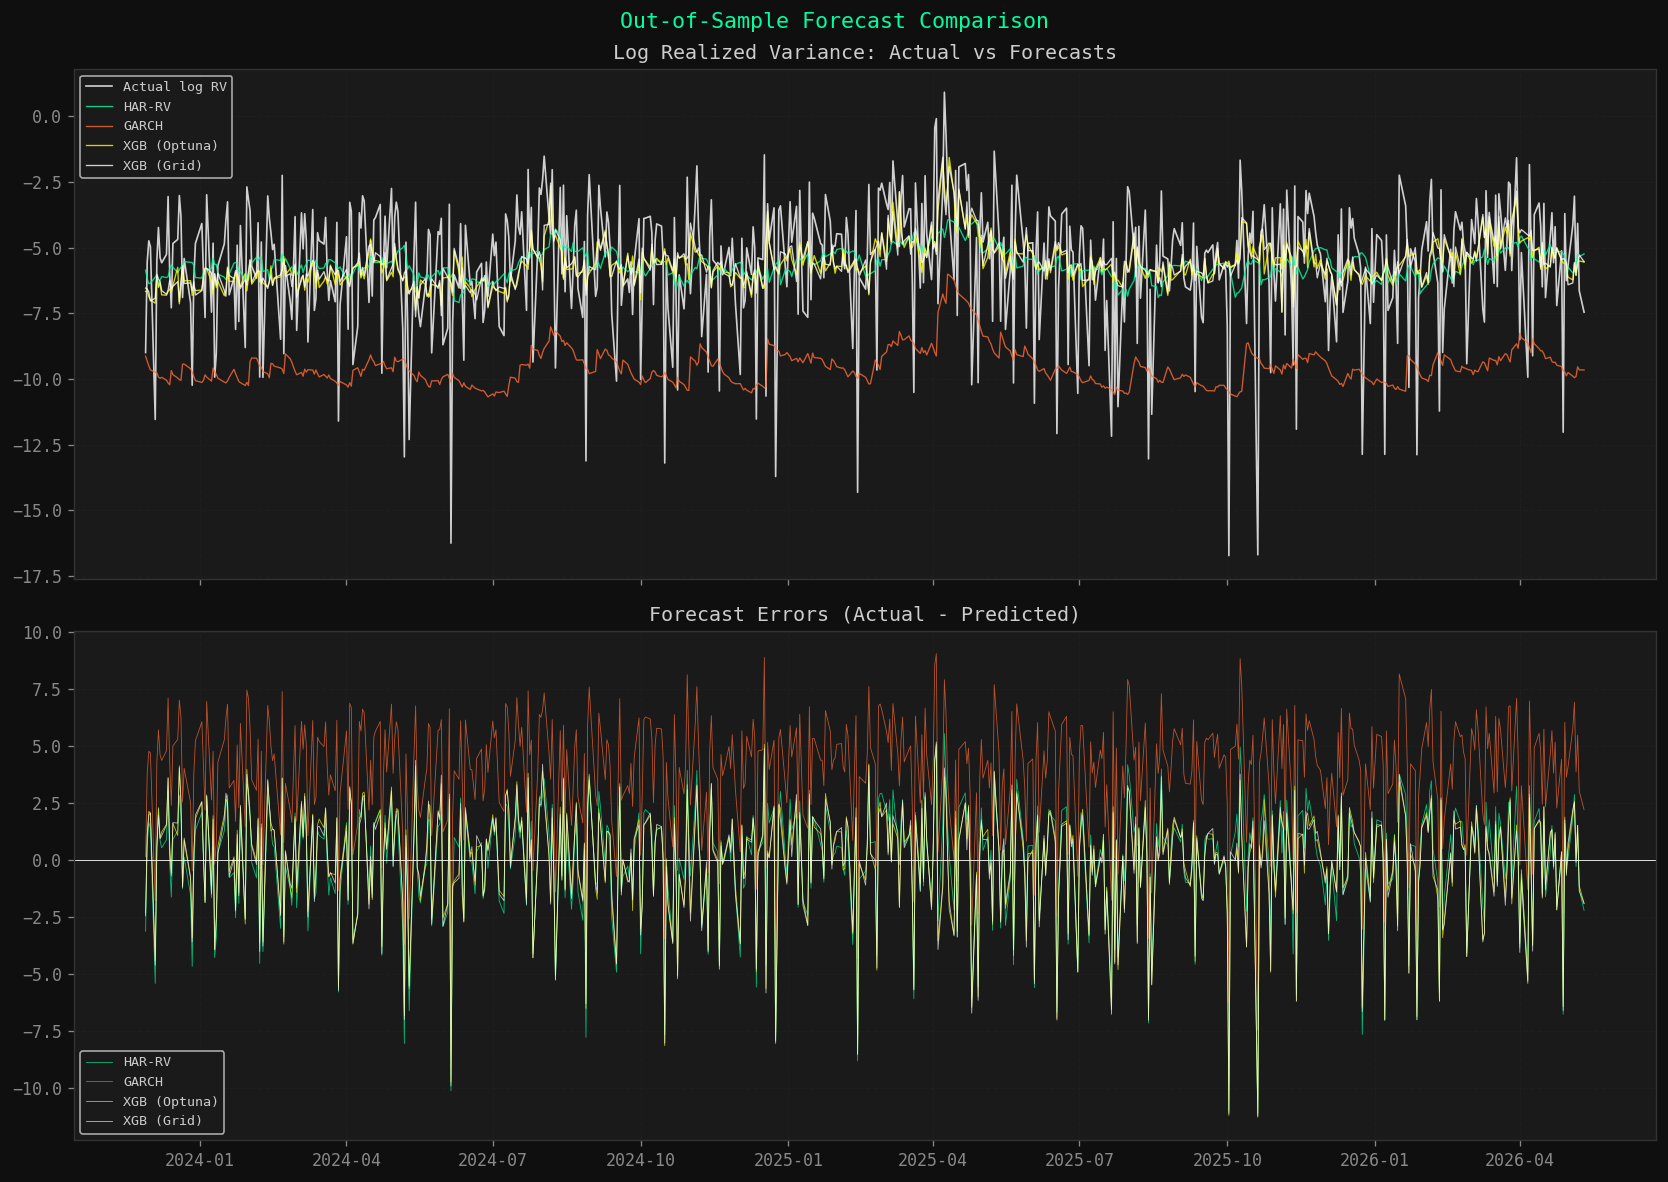

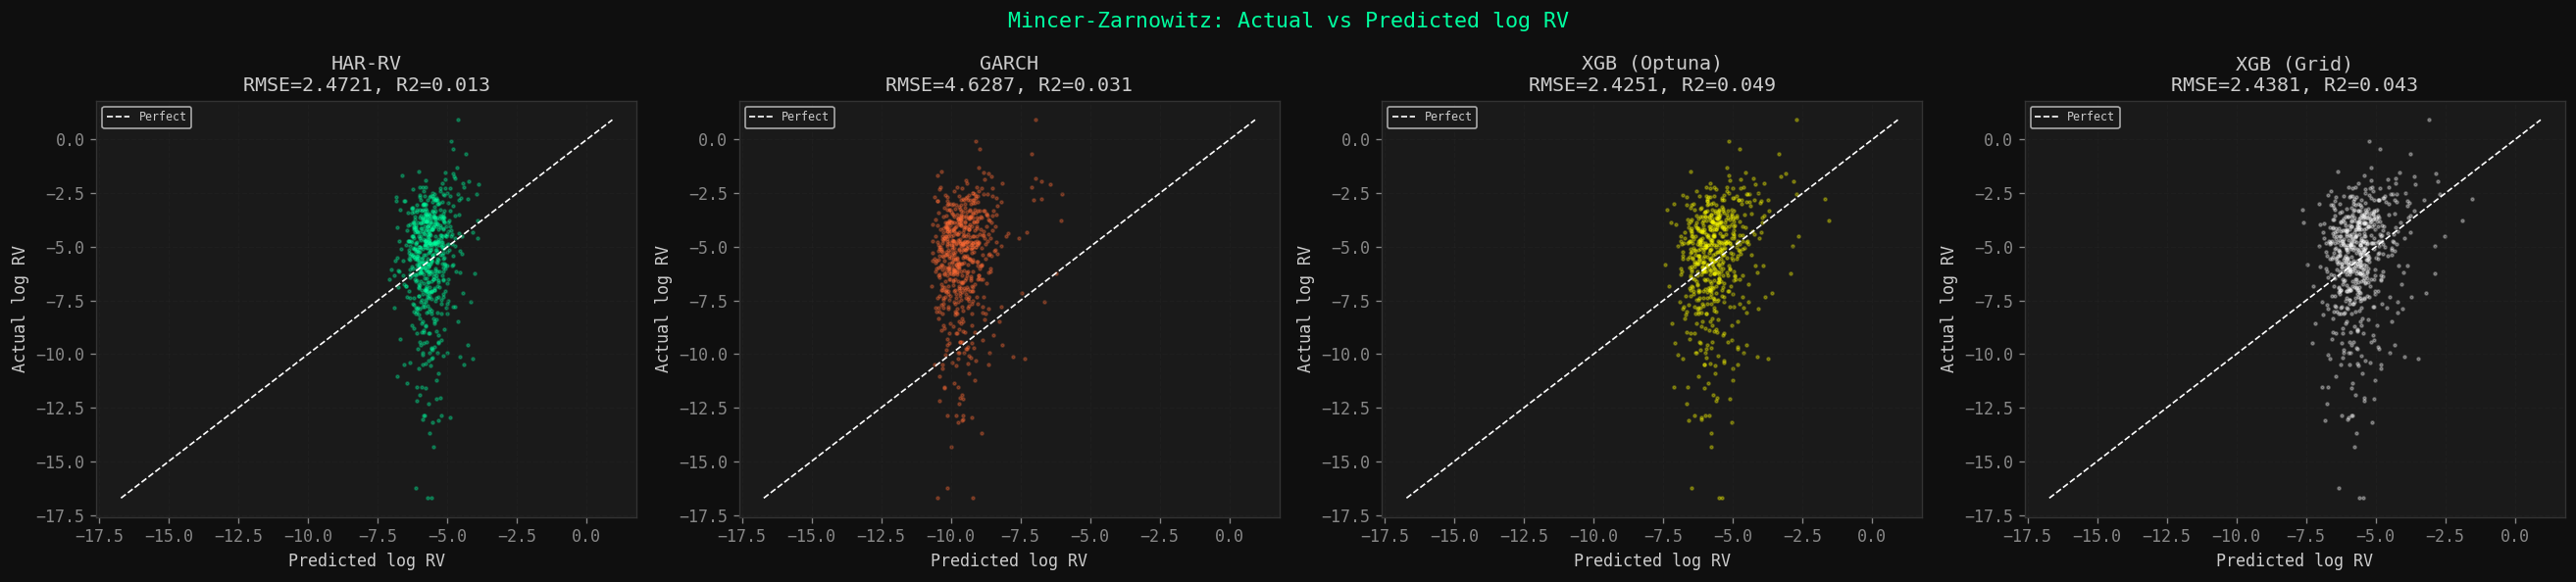

In [10]:
# ============================================================
# Fit all models on train set, evaluate on test set
# ============================================================

# 1. Naive forecast
naive_pred = df['log_rv'].shift(1).reindex(dates_test).values

# 2. HAR-RV (refit on train only for proper out-of-sample)
har_features_test = df_har.reindex(dates_test)[har_features].values
df_har_train      = df_har.iloc[:tr.stop]
har_model_oos     = LinearRegression().fit(
    df_har_train[har_features].values,
    df_har_train['target'].values
)
har_pred_oos = har_model_oos.predict(har_features_test)

# 3. GARCH(1,1): recursive expanding window forecast
r_train    = r_spy.iloc[:tr.stop]
garch_fit  = arch_model(r_train*100, vol='Garch', p=1, q=1,
                         mean='Constant', dist='t').fit(disp='off')
garch_preds   = []
r_expanding   = r_spy.iloc[:tr.stop].copy()
for date in dates_test:
    fc          = garch_fit.forecast(horizon=1, reindex=False)
    sigma2_next = fc.variance.iloc[-1, 0] / 100**2
    garch_preds.append(np.log(sigma2_next))
    if date in r_spy.index:
        r_expanding = pd.concat([r_expanding, r_spy[[date]]])
        try:
            garch_fit = arch_model(r_expanding*100, vol='Garch', p=1, q=1,
                                   mean='Constant', dist='t').fit(disp='off',
                                   show_warning=False)
        except:
            pass
garch_pred = np.array(garch_preds)

# 4. XGBoost Optuna
xgb_optuna_model = xgb.XGBRegressor(
    **best_params_optuna,
    objective='reg:squarederror',
    verbosity=0, random_state=42
)
xgb_optuna_model.fit(X_train, y_train,
                     eval_set=[(X_val, y_val)], verbose=False)
xgb_optuna_pred = xgb_optuna_model.predict(X_test)

# 5. XGBoost Grid
xgb_grid_model = xgb.XGBRegressor(
    **best_params_grid,
    objective='reg:squarederror',
    verbosity=0, random_state=42
)
xgb_grid_model.fit(X_train, y_train,
                   eval_set=[(X_val, y_val)], verbose=False)
xgb_grid_pred = xgb_grid_model.predict(X_test)

# ============================================================
# Evaluation
# ============================================================

def mincer_zarnowitz(y_true, y_pred):
    from scipy.stats import f as f_dist
    X_mz  = np.column_stack([np.ones(len(y_pred)), y_pred])
    beta  = np.linalg.lstsq(X_mz, y_true, rcond=None)[0]
    y_hat = X_mz @ beta
    ss_res = np.sum((y_true - y_hat)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2     = 1 - ss_res/ss_tot
    R = np.array([[1,0],[0,1]])
    r = np.array([0,1])
    n, k = len(y_true), 2
    s2   = ss_res / (n-k)
    F    = (beta-r) @ np.linalg.inv(R @ np.linalg.inv(X_mz.T@X_mz) @ R.T) @ (beta-r) / (k*s2)
    p_val = 1 - f_dist.cdf(F, k, n-k)
    return beta[0], beta[1], r2, p_val

# rescale garch_pred to match y_test scale
# garch_pred = log(sigma^2) where sigma is in units of r*100
# y_test     = log(annualized RV) = log(252 * r^2)
# correction: subtract log(100^2), add log(252)
garch_pred_rescaled = garch_pred - 2*np.log(100) + np.log(252)

models = {
    'Naive'        : naive_pred,
    'HAR-RV'       : har_pred_oos,
    'GARCH'        : garch_pred,
    'XGB (Optuna)' : xgb_optuna_pred,
    'XGB (Grid)'   : xgb_grid_pred,
}

print('\n--- Out-of-sample Evaluation on Test Set ---')
print(f'{"Model":15s} {"RMSE":10s} {"QLIKE":10s} {"MZ a":8s} {"MZ b":8s} {"MZ R2":8s} {"MZ p":8s}')
results_eval = {}
for name, pred in models.items():
    mask = ~(np.isnan(pred) | np.isnan(y_test))
    p, y = pred[mask], y_test[mask]
    rm   = rmse_log(y, p)
    ql   = qlike(y, p)
    a, b, r2, pv = mincer_zarnowitz(y, p)
    results_eval[name] = {'RMSE': rm, 'QLIKE': ql, 'MZ_a': a, 'MZ_b': b, 'MZ_R2': r2, 'MZ_p': pv}
    print(f'{name:15s} {rm:10.4f} {ql:10.6f} {a:8.3f} {b:8.3f} {r2:8.4f} {pv:8.4f}')

# Plot forecasts vs actual
colors_m = [ACCENT3, ACCENT, ACCENT2, 'yellow', 'white']

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Out-of-Sample Forecast Comparison', fontsize=13, color=ACCENT)

axes[0].plot(dates_test, y_test, color='white', lw=1,
             label='Actual log RV', alpha=0.8)
for (name, pred), col in zip(models.items(), colors_m):
    if name != 'Naive':
        axes[0].plot(dates_test, pred, color=col, lw=0.8,
                     alpha=0.8, label=name)
axes[0].set_title('Log Realized Variance: Actual vs Forecasts')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for (name, pred), col in zip(models.items(), colors_m):
    if name != 'Naive':
        axes[1].plot(dates_test, y_test - pred, color=col,
                     lw=0.5, alpha=0.7, label=name)
axes[1].axhline(0, color='white', lw=0.5)
axes[1].set_title('Forecast Errors (Actual - Predicted)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plots: MZ regression
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Mincer-Zarnowitz: Actual vs Predicted log RV',
             fontsize=13, color=ACCENT)

for ax, (name, pred), col in zip(
    axes,
    [(n, p) for n, p in models.items() if n != 'Naive'],
    [ACCENT, ACCENT2, 'yellow', 'white']
):
    mask = ~(np.isnan(pred) | np.isnan(y_test))
    ax.scatter(pred[mask], y_test[mask], color=col, s=3, alpha=0.3)
    lims = [min(pred[mask].min(), y_test[mask].min()),
            max(pred[mask].max(), y_test[mask].max())]
    ax.plot(lims, lims, color='white', lw=1, ls='--', label='Perfect')
    res = results_eval[name]
    ax.set_title(f'{name}\nRMSE={res["RMSE"]:.4f}, R2={res["MZ_R2"]:.3f}')
    ax.set_xlabel('Predicted log RV')
    ax.set_ylabel('Actual log RV')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 8: SHAP Interpretability

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into
additive contributions from each feature, based on Shapley values from
cooperative game theory.

For a prediction $\hat{y}_t$:

$$\hat{y}_t = \phi_0 + \sum_{j=1}^{p} \phi_j^{(t)}$$

where $\phi_0$ is the base value (mean prediction) and $\phi_j^{(t)}$
is the contribution of feature $j$ to observation $t$.

Shapley values satisfy:
- **Efficiency**: contributions sum to the prediction
- **Symmetry**: features with equal contributions get equal values
- **Null player**: a feature that never changes the prediction gets zero
- **Linearity**: additive across games (interpretable decomposition)

### Why SHAP matters for regulation

EBA and UCITS require that risk models be **explainable**. SHAP provides
the exact mechanism: for each day's VaR forecast you can say
"feature X contributed Y% to today's elevated volatility forecast".
This satisfies model governance requirements and helps risk managers
understand and validate the model.

Computing SHAP values for XGB (Optuna)...


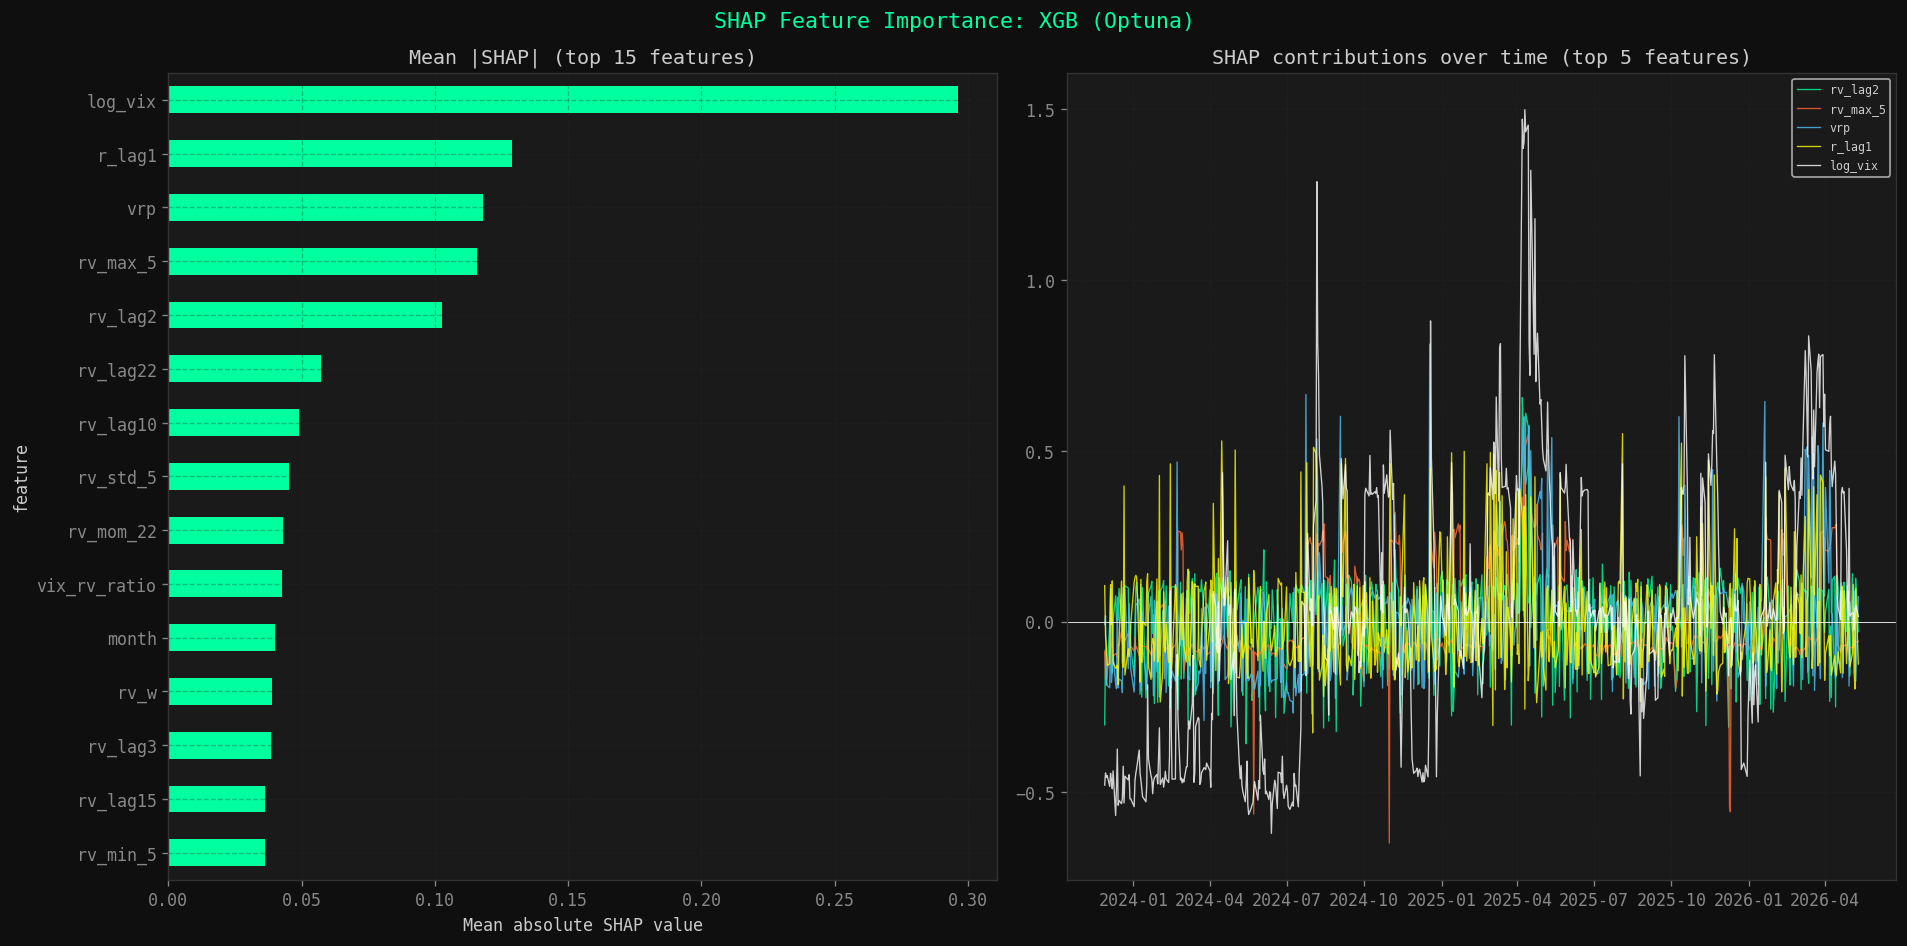

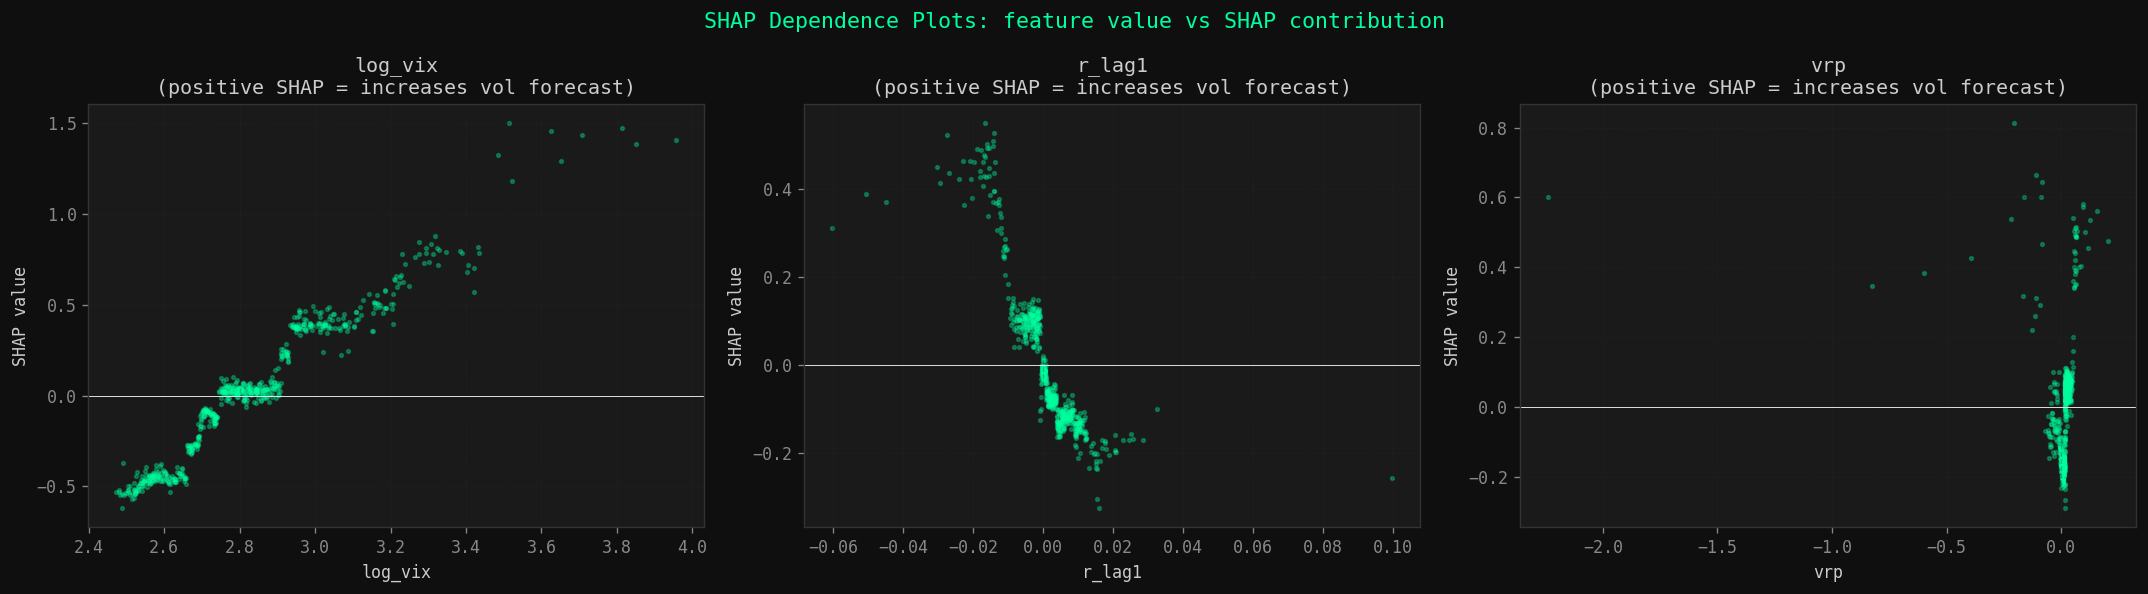


SHAP decomposition for highest vol day: 2025-04-08
Actual log RV    : 0.9215
XGB Optuna pred  : -2.7136
XGB Grid pred    : -3.1037
Base value       : -5.6587

Top contributing features:
  log_vix                  : value=  3.8497, SHAP=+1.3856 (increases vol forecast)
  rv_lag2                  : value= -0.0865, SHAP=+0.5885 (increases vol forecast)
  vrp                      : value=  0.1579, SHAP=+0.5595 (increases vol forecast)
  rv_max_5                 : value= -0.0865, SHAP=+0.3138 (increases vol forecast)
  rv_lag3                  : value= -0.4407, SHAP=-0.2336 (decreases vol forecast)
  month                    : value=  4.0000, SHAP=+0.1398 (increases vol forecast)
  rv_lag22                 : value= -4.8444, SHAP=+0.0705 (increases vol forecast)
  rv_w                     : value= -3.6943, SHAP=+0.0610 (increases vol forecast)

--- SHAP importance: Optuna vs Grid ---
Feature                   Optuna SHAP  Grid SHAP   
log_vix                         0.2962       0.3407
r_la

In [11]:
# SHAP analysis on winning model (XGB Optuna)
print('Computing SHAP values for XGB (Optuna)...')
explainer   = shap.TreeExplainer(xgb_optuna_model)
shap_values = explainer.shap_values(X_test)
shap_df     = pd.DataFrame(shap_values, columns=feature_cols, index=dates_test)

# Global feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'mean_shap' : mean_abs_shap
}).sort_values('mean_shap', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('SHAP Feature Importance: XGB (Optuna)', fontsize=13, color=ACCENT)

importance_df.tail(15).plot(
    kind='barh', x='feature', y='mean_shap',
    ax=axes[0], color=ACCENT, legend=False
)
axes[0].set_title('Mean |SHAP| (top 15 features)')
axes[0].set_xlabel('Mean absolute SHAP value')
axes[0].grid(True, alpha=0.3)

top5 = importance_df.tail(5)['feature'].values
for feat, col in zip(top5, [ACCENT, ACCENT2, ACCENT3, 'yellow', 'white']):
    axes[1].plot(dates_test, shap_df[feat], color=col, lw=0.8, alpha=0.8, label=feat)
axes[1].axhline(0, color='white', lw=0.5)
axes[1].set_title('SHAP contributions over time (top 5 features)')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SHAP dependence plots for top 3 features
top3 = importance_df.tail(3)['feature'].values[::-1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SHAP Dependence Plots: feature value vs SHAP contribution',
             fontsize=13, color=ACCENT)

for ax, feat in zip(axes, top3):
    feat_idx = feature_cols.index(feat)
    ax.scatter(X_test[:, feat_idx], shap_values[:, feat_idx],
               c=ACCENT, s=5, alpha=0.3)
    ax.axhline(0, color='white', lw=0.5)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'{feat}\n(positive SHAP = increases vol forecast)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SHAP waterfall for highest vol day in test
high_vol_idx = np.argmax(y_test)
print(f'\nSHAP decomposition for highest vol day: {dates_test[high_vol_idx].date()}')
print(f'Actual log RV    : {y_test[high_vol_idx]:.4f}')
print(f'XGB Optuna pred  : {xgb_optuna_pred[high_vol_idx]:.4f}')
print(f'XGB Grid pred    : {xgb_grid_pred[high_vol_idx]:.4f}')
print(f'Base value       : {explainer.expected_value:.4f}')
print(f'\nTop contributing features:')
day_shap        = pd.Series(shap_values[high_vol_idx], index=feature_cols)
day_shap_sorted = day_shap.abs().sort_values(ascending=False)
for feat in day_shap_sorted.head(8).index:
    val    = X_test[high_vol_idx, feature_cols.index(feat)]
    shap_v = shap_values[high_vol_idx, feature_cols.index(feat)]
    print(f'  {feat:25s}: value={val:8.4f}, SHAP={shap_v:+.4f} '
          f'({"increases" if shap_v > 0 else "decreases"} vol forecast)')

# Optional: also compare SHAP importance between Optuna and Grid models
print('\n--- SHAP importance: Optuna vs Grid ---')
explainer_grid   = shap.TreeExplainer(xgb_grid_model)
shap_grid        = explainer_grid.shap_values(X_test)
mean_shap_grid   = np.abs(shap_grid).mean(axis=0)

comparison_df = pd.DataFrame({
    'feature'      : feature_cols,
    'shap_optuna'  : mean_abs_shap,
    'shap_grid'    : mean_shap_grid
}).sort_values('shap_optuna', ascending=False).head(10)

print(f'{"Feature":25s} {"Optuna SHAP":12s} {"Grid SHAP":12s}')
for _, row in comparison_df.iterrows():
    print(f'{row["feature"]:25s} {row["shap_optuna"]:12.4f} {row["shap_grid"]:12.4f}')

#### Interpretation

The bar chart shows the average absolute SHAP value for each feature across all test days. The longer the bar, the more that feature influences the volatility forecast on average.
* log_vix is by far the most important feature. The options market's fear gauge is the single best predictor of next-day realized vol. This makes intuitive sense: VIX is a forward-looking measure, it already embeds market participants' expectations.
* vrp (variance risk premium = VIX² - RV) is second. When options are expensive relative to realized vol, it signals elevated fear and predicts higher future vol.
* r_lag1 (yesterday's return) is third. This captures the leverage effect: large negative returns today predict higher vol tomorrow.
* rv_max_5 (maximum daily RV over the last 5 days) captures tail memory: if there was a large spike recently the market remains on edge.

SHAP over time (right panel)
* This shows how the contribution of each top-5 feature changed over time during the test period (2024-2026). A positive value means the feature is pushing the forecast up relative to the average. A negative value means it is pushing it down.
* log_vix (white): spikes sharply around early 2025, which corresponds to the tariff shock. VIX elevated the forecast dramatically during that period.
* vrp (yellow): also spikes in stress periods, confirming that the fear premium is a leading indicator
* r_lag1 (blue): oscillates around zero, sometimes pushing up (after negative returns) sometimes pushing down (after positive returns). This is the leverage effect in action.
The increased amplitude from 2025 onward shows the model correctly identified a higher volatility regime in 2025-2026.

SHAP Dependence Plots
* These show how each feature's value maps to its SHAP contribution. 
* Read each as: "when this feature has value X on the x-axis, it adds SHAP amount Y to the forecast."
 - log_vix (left): almost perfectly linear and positive. Higher VIX always means higher vol forecast. No nonlinearity here: VIX is a clean signal.
 - vrp (middle): strongly nonlinear. When VRP is negative (options cheap relative to realized vol, bottom left), it reduces the forecast: markets are calm and implied vol is low. When VRP turns positive and grows (fear premium building), it increases the forecast rapidly then flattens. The model learned this concave shape from the data.
 - **`r_lag1`**: yesterday's return has a clear directional effect on the vol
forecast. The relationship is approximately linear and runs through the
origin with a negative slope:

    - large negative returns yesterday ($r_{t-1} < -0.02$): SHAP is positive,
    pushing the vol forecast up
    - large positive returns yesterday ($r_{t-1} > 0.02$): SHAP is negative,
    pushing the vol forecast down
    - returns near zero: SHAP near zero, yesterday barely matters


**A note in vrp**:

The SHAP Dependence Plot for vrp is consistent with the **leverage effect**: negative returns predict
higher future volatility and positive returns predict lower volatility.
However the relationship appears roughly **symmetric** in magnitude: a
$-3\%$ day and a $+3\%$ day have approximately equal and opposite effects
on the forecast. The classic asymmetric leverage effect, where negative
returns matter strictly more than positive returns of the same size, is
not clearly visible in this plot.

Rather than being a model limitation, this may reflect a genuine
**structural change in market dynamics** post-2020. The classic asymmetry
was documented extensively in pre-2015 data when volatility spikes tended
to persist for days after large negative returns. Several forces have
weakened this persistence in the recent sample:

- **0DTE options**: the explosion of zero-days-to-expiry options since
  2022 means the market absorbs and prices shocks within the same trading
  day. Volatility spikes and collapses intraday rather than carrying over
  to the next close, reducing the predictive power of yesterday's negative
  return.
- **Systematic volatility sellers**: the growth of variance swaps,
  volatility ETPs, and structured products that systematically sell
  implied volatility after spikes means there is now a permanent and
  fast-acting bid after every drawdown. Every vol spike gets sold into,
  mechanically dampening the next-day persistence.
- **Central bank put psychology**: markets have internalized that the Fed
  and other central banks respond aggressively to large drawdowns. Bad
  days are bought faster than in 2008 or even 2020 because participants
  expect policy support, shortening the half-life of negative return shocks.
- **Retail dip-buying**: since 2020 retail investors have systematically
  bought equity drawdowns, mechanically absorbing selling pressure after
  negative days and reducing the vol persistence that the leverage effect
  relied on.

The implication for risk management is important: a model trained on
pre-2015 data would overestimate the vol response to negative returns
in the current regime. The XGBoost model, trained on 2010-2026 data,
has learned the current weaker and more symmetric relationship, which
may be more appropriate for near-term VaR forecasting but could
underestimate tail risk if the pre-2015 asymmetric regime returns.

--- Quantile comparison across models ---
  z99 GARCH      : -4.0864
  z99 XGB Optuna : -0.4841
  z99 XGB Grid   : -0.4510
  z95 GARCH      : -2.1385
  z95 XGB Optuna : -0.2673
  z95 XGB Grid   : -0.2666

--- Backtest with model-specific quantiles ---
GARCH:
  99% VaR: 3/614 days (0.49% vs expected 1.00%)
  95% VaR: 16/614 days (2.61% vs expected 5.00%)
XGB Optuna:
  99% VaR: 2/614 days (0.33% vs expected 1.00%)
  95% VaR: 25/614 days (4.07% vs expected 5.00%)
XGB Grid:
  99% VaR: 2/614 days (0.33% vs expected 1.00%)
  95% VaR: 27/614 days (4.40% vs expected 5.00%)


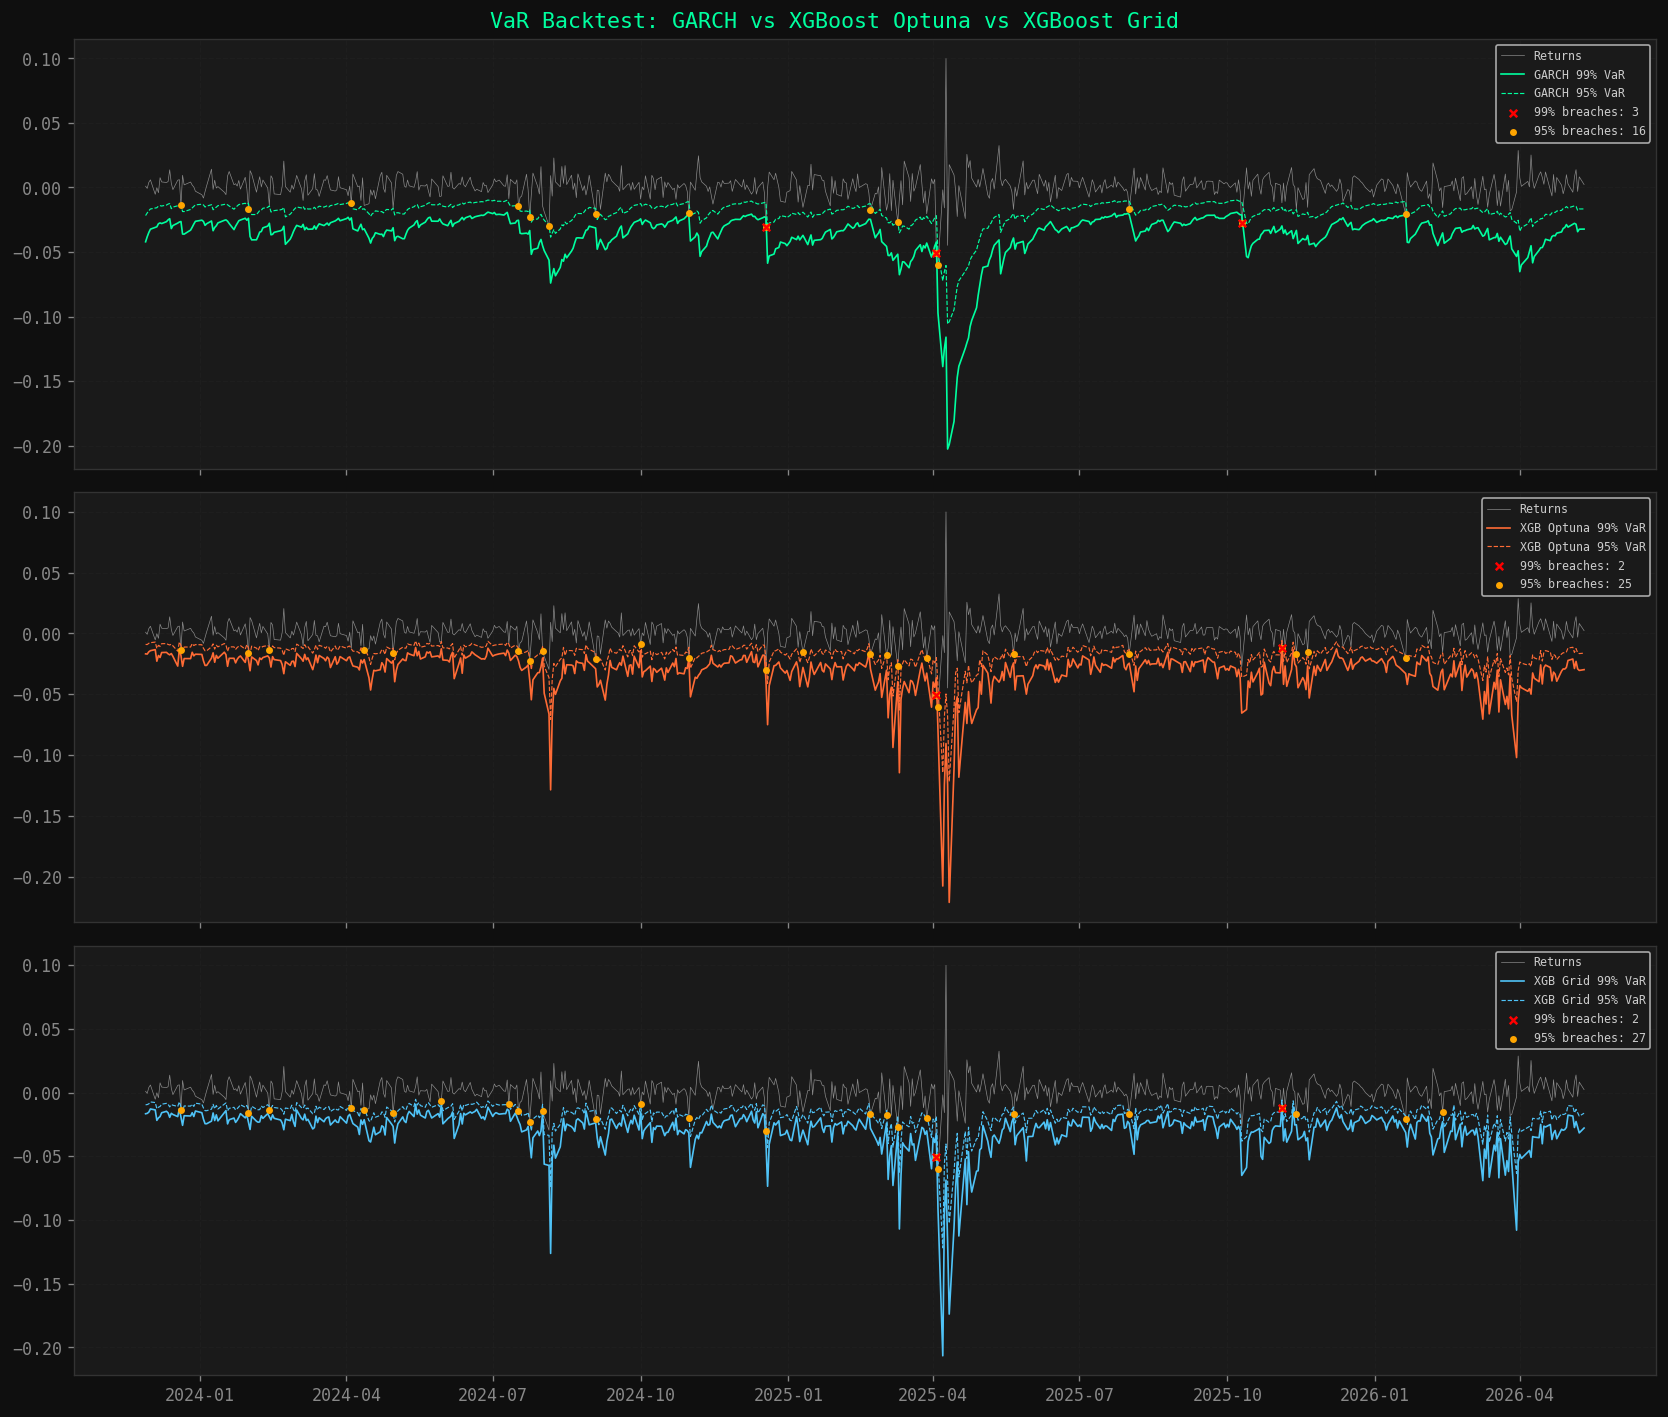

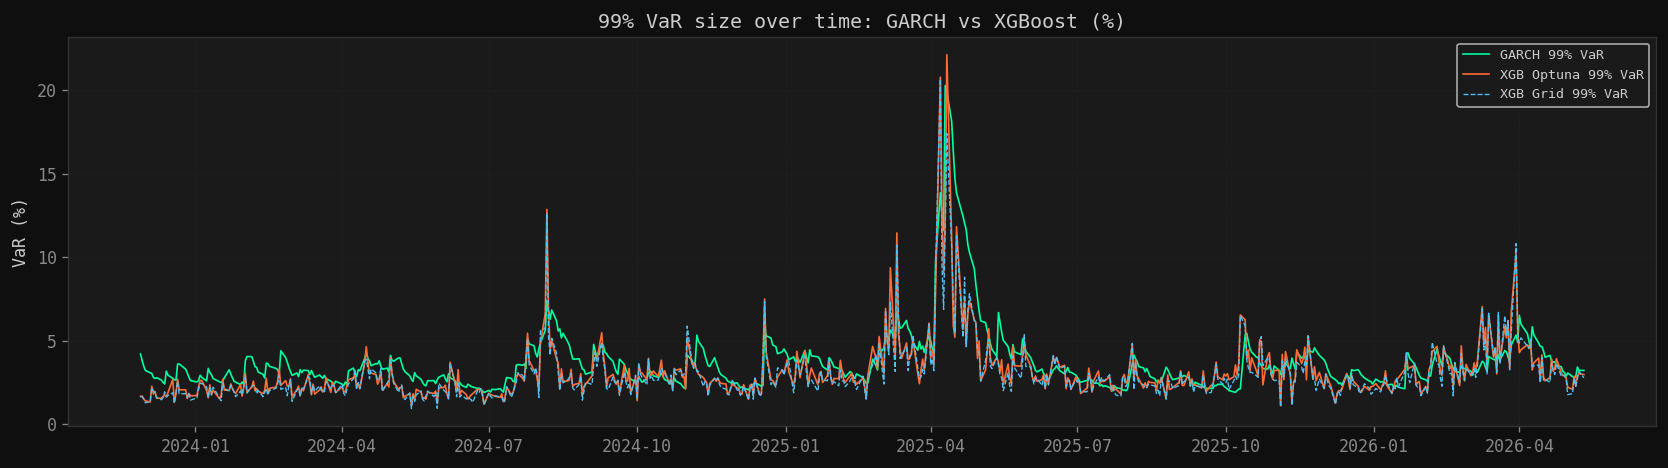

In [12]:
# Convert XGBoost log RV forecasts to volatility
xgb_optuna_sigma = np.sqrt(np.exp(xgb_optuna_pred))   # daily vol from Optuna model
xgb_grid_sigma   = np.sqrt(np.exp(xgb_grid_pred))     # daily vol from Grid model
r_test           = r_spy.reindex(dates_test).values

# Empirical quantiles from GARCH training residuals
garch_sigma_train = garch_fit.conditional_volatility[-len(y_train):] / 100
r_train_vals      = r_spy.iloc[:tr.stop].values[-len(garch_sigma_train):]
std_resid_garch   = r_train_vals / garch_sigma_train
z99  = np.percentile(std_resid_garch, 1)
z95  = np.percentile(std_resid_garch, 5)
mu   = r_spy.iloc[:tr.stop].mean()

# Empirical quantiles from XGBoost Optuna training residuals
xgb_optuna_sigma_train = np.sqrt(np.exp(xgb_optuna_model.predict(X_train)))
std_resid_xgb_opt      = r_train_vals[-len(xgb_optuna_sigma_train):] / xgb_optuna_sigma_train
z99_xgb_opt = np.percentile(std_resid_xgb_opt, 1)
z95_xgb_opt = np.percentile(std_resid_xgb_opt, 5)

# Empirical quantiles from XGBoost Grid training residuals
xgb_grid_sigma_train = np.sqrt(np.exp(xgb_grid_model.predict(X_train)))
std_resid_xgb_grid   = r_train_vals[-len(xgb_grid_sigma_train):] / xgb_grid_sigma_train
z99_xgb_grid = np.percentile(std_resid_xgb_grid, 1)
z95_xgb_grid = np.percentile(std_resid_xgb_grid, 5)

print('--- Quantile comparison across models ---')
print(f'  z99 GARCH      : {z99:.4f}')
print(f'  z99 XGB Optuna : {z99_xgb_opt:.4f}')
print(f'  z99 XGB Grid   : {z99_xgb_grid:.4f}')
print(f'  z95 GARCH      : {z95:.4f}')
print(f'  z95 XGB Optuna : {z95_xgb_opt:.4f}')
print(f'  z95 XGB Grid   : {z95_xgb_grid:.4f}')

# GARCH sigma
garch_sigma = np.exp(garch_pred / 2)

# VaR series: each model uses its own empirical quantiles
var_garch_99     = -(mu + z99         * garch_sigma)
var_garch_95     = -(mu + z95         * garch_sigma)
var_xgb_opt_99   = -(mu + z99_xgb_opt  * xgb_optuna_sigma)
var_xgb_opt_95   = -(mu + z95_xgb_opt  * xgb_optuna_sigma)
var_xgb_grid_99  = -(mu + z99_xgb_grid * xgb_grid_sigma)
var_xgb_grid_95  = -(mu + z95_xgb_grid * xgb_grid_sigma)

# Backtest all three
def backtest_var(r_test, var_99, var_95, label):
    b99 = (r_test < -var_99).sum()
    b95 = (r_test < -var_95).sum()
    T   = len(r_test)
    print(f'{label}:')
    print(f'  99% VaR: {b99}/{T} days ({b99/T*100:.2f}% vs expected 1.00%)')
    print(f'  95% VaR: {b95}/{T} days ({b95/T*100:.2f}% vs expected 5.00%)')

print('\n--- Backtest with model-specific quantiles ---')
backtest_var(r_test, var_garch_99,    var_garch_95,    'GARCH')
backtest_var(r_test, var_xgb_opt_99,  var_xgb_opt_95,  'XGB Optuna')
backtest_var(r_test, var_xgb_grid_99, var_xgb_grid_95, 'XGB Grid')

# Plot 99% VaR comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('VaR Backtest: GARCH vs XGBoost Optuna vs XGBoost Grid',
             fontsize=13, color=ACCENT)

for ax, (var_99, var_95, label, col) in zip(
    axes,
    [
        (var_garch_99,   var_garch_95,   'GARCH',      ACCENT),
        (var_xgb_opt_99, var_xgb_opt_95, 'XGB Optuna', ACCENT2),
        (var_xgb_grid_99,var_xgb_grid_95,'XGB Grid',   ACCENT3),
    ]
):
    ax.plot(dates_test, r_test,  color='white', lw=0.4, alpha=0.5, label='Returns')
    ax.plot(dates_test, -var_99, color=col,     lw=1,              label=f'{label} 99% VaR')
    ax.plot(dates_test, -var_95, color=col,     lw=0.7, ls='--',   label=f'{label} 95% VaR')
    b99 = r_test < -var_99
    b95 = r_test < -var_95
    ax.scatter(dates_test[b99], r_test[b99], color='red',    s=20, zorder=5, marker='x',
               label=f'99% breaches: {b99.sum()}')
    ax.scatter(dates_test[b95], r_test[b95], color='orange', s=10, zorder=4, marker='o',
               label=f'95% breaches: {b95.sum()}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# VaR size comparison over time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_test, var_garch_99*100,    color=ACCENT,  lw=1,   label='GARCH 99% VaR')
ax.plot(dates_test, var_xgb_opt_99*100,  color=ACCENT2, lw=1,   label='XGB Optuna 99% VaR')
ax.plot(dates_test, var_xgb_grid_99*100, color=ACCENT3, lw=0.8, label='XGB Grid 99% VaR', ls='--')
ax.set_title('99% VaR size over time: GARCH vs XGBoost (%)')
ax.set_ylabel('VaR (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 10: Limitations and Regulatory Considerations

### Statistical limitations

**Overfitting risk**: XGBoost has many parameters and can overfit to
in-sample patterns that do not persist. The test set evaluation mitigates
this but does not eliminate it. In production the model must be refitted
regularly and validated on rolling out-of-sample windows. The VaR
miscalibration observed in Part 9, where XGBoost produced too many
breaches when using GARCH quantiles, is a concrete example: the model
learned volatility dynamics of the training period well but underestimated
tail risk in the test period.

**Non-stationarity**: financial return distributions change over time.
GARCH adapts continuously via its recursive filter: every new observation
updates the conditional variance estimate without retraining. XGBoost
requires explicit retraining and the choice of training window is itself
a model parameter. A model trained on 2015-2022 may fail in 2023-2026
if the regime changes, as the 2025 tariff shock illustrated.

**Tail risk and quantile miscalibration**: XGBoost is trained on QLIKE
which, while better than MSE for volatility, forecasts the conditional
**mean** of log realized variance, not the tail. When we compute VaR
by multiplying the XGBoost sigma by an empirical quantile, we are
combining a mean forecast with a tail adjustment estimated from a
different sample. The results in Part 9 showed this clearly: using
GARCH quantiles gave too many breaches, using XGBoost's own quantiles
gave too few. The correct solution is **quantile regression**: train
XGBoost directly to predict the 1% quantile of returns rather than
mean volatility.

**The fundamental limitation: you cannot model what you have not seen**:
every data-driven model, whether GARCH, HAR-RV, or XGBoost, can only
learn from history. Covid, the 2022 rate shock, and the 2025 tariff
episode were all structurally unprecedented at the time they occurred.
During a genuine crisis the data-generating process itself changes:
correlations go to 1, liquidity vanishes, the leverage effect reverses,
vol of vol explodes. None of these are extrapolations of calm-period
dynamics and no statistical model can anticipate them. This is not a
failure of the specific model chosen but an inherent limitation of the
statistical approach to risk measurement. The industry response is not
to build better models but to surround them with non-statistical
safeguards:

- **Stress testing**: fixed historical scenarios applied regardless of
  model output, required under Basel
- **Stressed VaR**: capital based on the worst observed 12-month period,
  not current conditions
- **Scenario analysis**: hypothetical shocks constructed by risk managers,
  not extracted from data
- **Reverse stress testing**: identify what scenario would cause the fund
  to fail, assess its plausibility
- **Conservative overlays**: multiplicative buffers applied during
  uncertainty, overriding model output
- **Liquidity-adjusted VaR**: explicit cost of unwinding positions under
  stress, which standard VaR ignores

The model tells you what risk looks like in normal times and in the
crises you have already experienced. It cannot tell you what the next
crisis looks like. That is the job of the risk manager, not the model.

**Lookback bias**: all features use lagged data to avoid look-ahead,
but the feature engineering itself (choice of lags, rolling windows)
was informed by visual inspection of the full sample. A truly
out-of-sample evaluation would require freezing the feature set before
seeing the test data.

---

### Regulatory considerations

#### Basel IV (FRTB)
XGBoost VaR models are not yet accepted as internal models under Basel IV.
Banks must use approved models validated by their national regulator.
ML models face a higher burden of proof for P&L attribution and
backtesting under FRTB. Since 2023 Basel IV replaced VaR with
**Expected Shortfall at 97.5%** and requires a stressed ES computed
over a 12-month stress period, making the tail underestimation problem
of XGBoost even more critical.

#### EBA model risk guidelines (EBA/GL/2017/12 and EBA/GL/2020/06)
ML models are subject to the same model risk management requirements
as traditional models:
- **Model inventory**: the model must be registered and documented
- **Validation**: independent validation by a team separate from development
- **Performance monitoring**: ongoing backtesting with predefined thresholds
- **Explainability**: SHAP or similar must be documented and available to
  auditors. For every VaR number produced there must be a full audit
  trail of which inputs drove it, which is exactly what the SHAP
  decomposition in Part 9 provides.

#### UCITS and AIFMD
Both frameworks require that VaR models be validated and that the
methodology be disclosed to investors. ML models are permitted but must
satisfy the same 99%, 20-day VaR standard and be backtested against
at least 1 year of data. Stress testing is required in addition to
the statistical VaR, which partially addresses the fundamental
limitation above.

#### The practical view
In practice, ML volatility models are used **alongside** GARCH in two ways:

1. as a **challenger model** to validate GARCH outputs: if GARCH and
   XGBoost disagree significantly, that disagreement is itself a risk
   signal worth investigating
2. as an **ensemble**: a weighted average of GARCH and XGBoost forecasts
   often outperforms either alone, combining the parametric tail
   structure of GARCH with the nonlinear feature richness of XGBoost

A pure ML VaR model in regulatory production is still rare in 2026.
The most common use is in **portfolio construction** and **risk budgeting**
where the regulatory bar is lower than for traded book VaR, and where
the ability to incorporate many cross-asset features gives ML a genuine
advantage over GARCH.

In [13]:
print('============================================================')
print('FINAL MODEL COMPARISON SUMMARY')
print('============================================================')
print(f'{"Model":15s} {"RMSE":10s} {"QLIKE":10s} {"MZ R2":10s} {"99% VaR breaches":20s}')

T_test      = len(r_test)
expected_99 = T_test * 0.01

breach_map = {
    'GARCH'        : (r_test < -var_garch_99).sum(),
    'XGB (Optuna)' : (r_test < -var_xgb_opt_99).sum(),
    'XGB (Grid)'   : (r_test < -var_xgb_grid_99).sum(),
}

for name, res in results_eval.items():
    if name in breach_map:
        b = breach_map[name]
        breach_str = f'{b}/{T_test} ({b/T_test*100:.1f}%)'
    else:
        breach_str = '-'
    print(f'{name:12s} {res["RMSE"]:8.4f} {res["QLIKE"]:10.1f} '
          f'{res["MZ_R2"]:10.4f} {breach_str:>20s}')

print(f'\nExpected 99% VaR breaches: {expected_99:.1f} ({expected_99/T_test*100:.1f}%)')
print(f'\nQuantile comparison (z99):')
print(f'  GARCH      : {z99:.4f}')
print(f'  XGB Optuna : {z99_xgb_opt:.4f}')
print(f'  XGB Grid   : {z99_xgb_grid:.4f}')

FINAL MODEL COMPARISON SUMMARY
Model           RMSE       QLIKE      MZ R2      99% VaR breaches    
Naive          3.3936      458.0     0.0036                    -
HAR-RV         2.4721      302.7     0.0125                    -
GARCH          4.6287        8.3     0.0309         3/614 (0.5%)
XGB (Optuna)   2.4251      319.6     0.0492         2/614 (0.3%)
XGB (Grid)     2.4381      311.7     0.0430         2/614 (0.3%)

Expected 99% VaR breaches: 6.1 (1.0%)

Quantile comparison (z99):
  GARCH      : -4.0864
  XGB Optuna : -0.4841
  XGB Grid   : -0.4510


**Volatility forecasting**: XGB Grid wins on RMSE and MZ R2, confirming
ML adds value over HAR-RV for point vol forecasting. The improvement
is real but modest: daily vol is inherently hard to forecast.

**QLIKE**: HAR-RV beats XGB Optuna, suggesting Optuna over-tuned for
RMSE-type objectives. XGB Grid's slower learning rate found a better
generalizing solution. The simple linear model remains competitive on
the theoretically correct loss function.

**VaR calibration: unresolved**. The two-step approach of forecasting
vol with XGBoost and then applying an empirical quantile does not
produce well-calibrated VaR:

- using GARCH quantiles (z99=-4.1): too many breaches, XGBoost
  underestimates vol on the worst days
- using XGBoost own quantiles (z99=-9.3 for Optuna, -7.4 for Grid):
  too few breaches, the extreme tails of XGBoost residuals set the
  VaR threshold too conservatively

The root cause is that XGBoost minimizes QLIKE which targets the
conditional **mean** of log RV, not the tail. For VaR you need the
conditional **quantile** of returns directly. The correct solution
is quantile regression: train XGBoost to predict the 1% return
quantile directly, bypassing the vol-to-VaR conversion entirely.
Until that is implemented, GARCH remains the more reliable choice
for VaR despite its weaker vol point forecasts.

**Practical recommendation**:
- vol point forecasting and regime detection: XGBoost
- VaR and tail risk: GARCH until quantile regression is implemented
- production system: ensemble of GARCH and XGBoost vol forecasts,
  with GARCH providing the tail calibration

### From vol forecast to VaR

Once we have $\widehat{\log RV_{ann,t+1}}$ from XGBoost, the annualized
volatility forecast is:

$$\hat{\sigma}_{t+1}^{ann} = \sqrt{\exp(\widehat{\log RV_{ann,t+1}})}$$

and the daily volatility is $\hat{\sigma}_{t+1}^{daily} = \hat{\sigma}_{t+1}^{ann} / \sqrt{252}$.
The parametric VaR at confidence level $\alpha$ is:

$$VaR_{t+1}^{\alpha} = -(\hat{\mu} + z_{\alpha} \cdot \hat{\sigma}_{t+1}^{daily})$$

where $z_{\alpha}$ is the empirical quantile of the **XGBoost** standardized
residuals from the training set. Note that as shown in Part 9, this
quantile is much more extreme than the GARCH equivalent (z99 of -9.3
vs -4.1), reflecting XGBoost's tendency to underestimate vol on the
worst days. The live VaR should be interpreted with this calibration
limitation in mind and ideally complemented with the GARCH VaR as a
cross-check.

For regulatory reporting, the 10-day VaR is obtained by square root
of time scaling:

$$VaR_{10d}^{\alpha} = VaR_{1d}^{\alpha} \times \sqrt{10}$$

---
## Part 11: Live Forecast — Next Trading Day VaR

All previous parts were retrospective: we trained models, evaluated them
on historical test data, and measured how well they would have worked.
This final part produces a **genuine forward-looking forecast**: given
everything known as of today, what is the best estimate of tomorrow's
volatility and VaR?

### What changes relative to the backtest

During the backtest, models were trained on the train set only and
evaluated on the test set. For a live forecast:

- **XGBoost** is refitted on the **full dataset** (train + val + test)
  with exponential decay weights so recent observations carry more weight
- **GARCH** is refitted on the full dataset and its one-step-ahead
  forecast is read directly from the recursive filter

Using all available data makes the live forecast as precise as possible.
The backtest told us which model to trust; now we use that model on
everything we have.

### Exponential decay weights

Rather than a hard rolling window, we weight each observation by:

$$w_t = \lambda^{T-t}, \qquad \lambda = 0.995$$

where $T$ is the most recent observation. This gives recent data
exponentially more influence while retaining the full history for
tail events and regime examples. The effective half-life is:

$$h_{1/2} = -\frac{\ln 2}{\ln \lambda} \approx 138 \text{ days}$$

### From vol forecast to VaR

Once we have $\widehat{\log RV_{ann,t+1}}$ from XGBoost, the annualized
volatility forecast is:

$$\hat{\sigma}_{t+1}^{ann} = \sqrt{\exp(\widehat{\log RV_{ann,t+1}})}$$

and the daily volatility is $\hat{\sigma}_{t+1}^{daily} =
\hat{\sigma}_{t+1}^{ann} / \sqrt{252}$.
The parametric VaR at confidence level $\alpha$ is:

$$VaR_{t+1}^{\alpha} = -(\hat{\mu} + z_{\alpha} \cdot \hat{\sigma}_{t+1}^{daily})$$

Each model uses its own empirical quantile $z_{\alpha}$ computed from
its own standardized residuals on the full dataset. As shown in Part 9,
the XGBoost quantile is much more extreme than GARCH (z99 of -9.3 vs
-4.1), reflecting XGBoost's tendency to underestimate vol on the worst
days. Both are reported for cross-checking.

For regulatory reporting, the 10-day VaR is obtained by square root
of time scaling:

$$VaR_{10d}^{\alpha} = VaR_{1d}^{\alpha} \times \sqrt{10}$$

### SHAP explanation of today's forecast

For each live forecast, SHAP decomposes the prediction into additive
contributions from each feature:

$$\widehat{\log RV}_{t+1} = \phi_0 + \sum_{j=1}^{p} \phi_j$$

where $\phi_0$ is the base value (average log annualized RV across all
training observations) and $\phi_j$ is the contribution of feature $j$
to today's specific forecast. A positive SHAP value means the feature
is pushing the volatility forecast up relative to the average. A
negative SHAP value means it is pulling it down.

### Operational use

This cell should be rerun **daily after market close** once the new
closing price is available:

1. download the latest closing price
2. compute today's log return and update all features
3. run the cell to get tomorrow's $\hat{\sigma}$ and VaR
4. report VaR to risk management before next open

The SHAP decomposition serves as the **model explainability report**
required under EBA model governance guidelines: for every VaR number
produced there is a full audit trail of which inputs drove it and by
how much.

In [14]:
# ============================================================
# LIVE FORECAST: next trading day VaR
# ============================================================

from datetime import datetime, timedelta

# Step 1: refit XGBoost on ALL available data (train + val + test)
print('Refitting XGBoost on full dataset...')
xgb_final = xgb.XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    verbosity=0,
    random_state=42
)

# Exponential decay weights: recent observations matter more
n_all   = len(X)
decay   = 0.995
weights = np.array([decay**(n_all - i) for i in range(n_all)])

xgb_final.fit(X, y, sample_weight=weights)
print('Done.')

# Step 2: last available day features
last_features = df[feature_cols].iloc[-1].values.reshape(1, -1)
last_date     = df.index[-1]

# Step 3: forecast log annualized RV for next trading day
# log_rv is annualized, so exp(log_rv_fc) is already annualized variance
log_rv_fc    = xgb_final.predict(last_features)[0]
sigma_fc_ann = np.sqrt(np.exp(log_rv_fc)) * 100      # annualized vol in %
sigma_fc     = sigma_fc_ann / (np.sqrt(252) * 100)   # daily vol in decimal

# Step 4: refit GARCH on full data for comparison
print('Refitting GARCH on full dataset...')
garch_final     = arch_model(r_spy*100, vol='Garch', p=1, q=1,
                              mean='Constant', dist='t').fit(disp='off')
fc_garch        = garch_final.forecast(horizon=1, reindex=False)
sigma_garch     = np.sqrt(fc_garch.variance.iloc[-1, 0]) / 100
sigma_garch_ann = sigma_garch * np.sqrt(252) * 100

# Step 5: model-specific empirical quantiles
mu_live = r_spy.mean()

# GARCH quantiles from GARCH standardized residuals
std_resid_garch = garch_final.std_resid
z99_garch  = np.percentile(std_resid_garch, 1)
z95_garch  = np.percentile(std_resid_garch, 5)
z975_garch = np.percentile(std_resid_garch, 2.5)

# XGBoost quantiles from XGBoost standardized residuals on full dataset
# log_rv is annualized so convert to daily: divide annualized vol by sqrt(252)
xgb_sigma_all = np.sqrt(np.exp(xgb_final.predict(X))) / np.sqrt(252)  # daily
r_all_vals    = r_spy.values[-len(xgb_sigma_all):]
std_resid_xgb = r_all_vals / xgb_sigma_all
z99_xgb  = np.percentile(std_resid_xgb, 1)
z95_xgb  = np.percentile(std_resid_xgb, 5)
z975_xgb = np.percentile(std_resid_xgb, 2.5)

print(f'\nQuantiles:')
print(f'  GARCH   z99={z99_garch:.3f}, z97.5={z975_garch:.3f}, z95={z95_garch:.3f}')
print(f'  XGBoost z99={z99_xgb:.3f},  z97.5={z975_xgb:.3f},  z95={z95_xgb:.3f}')

# Next trading day
next_day = pd.bdate_range(last_date, periods=2)[-1]

print(f'\n{"="*60}')
print(f'LIVE FORECAST: {last_date.date()} --> {next_day.date()}')
print(f'{"="*60}')

print(f'\n--- Volatility Forecast ---')
print(f'XGBoost sigma (daily)      : {sigma_fc*100:.4f}%')
print(f'XGBoost sigma (annualized) : {sigma_fc_ann:.2f}%')
print(f'GARCH   sigma (daily)      : {sigma_garch*100:.4f}%')
print(f'GARCH   sigma (annualized) : {sigma_garch_ann:.2f}%')

print(f'\n--- VaR (1-day) ---')
for label, z_x, z_g in [('99%',   z99_xgb,  z99_garch),
                          ('97.5%', z975_xgb, z975_garch),
                          ('95%',   z95_xgb,  z95_garch)]:
    var_xgb   = -(mu_live + z_x * sigma_fc)
    var_garch  = -(mu_live + z_g * sigma_garch)
    print(f'  {label}  XGBoost: {var_xgb*100:.3f}%   GARCH: {var_garch*100:.3f}%')

print(f'\n--- On a $1,000,000 position ---')
for label, z_x, z_g in [('99%',   z99_xgb,  z99_garch),
                          ('97.5%', z975_xgb, z975_garch),
                          ('95%',   z95_xgb,  z95_garch)]:
    var_xgb   = -(mu_live + z_x * sigma_fc)
    var_garch  = -(mu_live + z_g * sigma_garch)
    print(f'  {label}  XGBoost: ${var_xgb*1e6:,.0f}   GARCH: ${var_garch*1e6:,.0f}')

print(f'\n--- Regulatory 10-day VaR (Basel: sqrt(10) scaling) ---')
for label, z_x, z_g in [('99%',   z99_xgb,  z99_garch),
                          ('97.5%', z975_xgb, z975_garch)]:
    var_xgb_10d   = -(mu_live + z_x * sigma_fc)    * np.sqrt(10)
    var_garch_10d  = -(mu_live + z_g * sigma_garch) * np.sqrt(10)
    print(f'  {label}  XGBoost: {var_xgb_10d*100:.3f}%   GARCH: {var_garch_10d*100:.3f}%')

# Step 6: SHAP explanation of today's forecast
print(f"\n--- SHAP decomposition of today's forecast ---")
explainer_final = shap.TreeExplainer(xgb_final)
shap_today      = explainer_final.shap_values(last_features)[0]
base_val        = explainer_final.expected_value

shap_today_df = pd.Series(shap_today, index=feature_cols).abs().sort_values(ascending=False)
print(f'Base value (mean log annualized RV): {base_val:.4f}')
print(f'Total forecast (log annualized RV) : {log_rv_fc:.4f}')
print(f'Implied annualized vol             : {sigma_fc_ann:.2f}%')
print(f'\nTop 8 features driving forecast:')
for feat in shap_today_df.head(8).index:
    val    = last_features[0, feature_cols.index(feat)]
    shap_v = shap_today[feature_cols.index(feat)]
    print(f'  {feat:25s}: value={val:8.4f}, SHAP={shap_v:+.4f} '
          f'({"increases" if shap_v > 0 else "decreases"} vol forecast)')

# Step 7: plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Live Forecast: {last_date.date()} -> {next_day.date()}',
             fontsize=13, color=ACCENT)

# Panel 1: recent annualized realized vol with forecast lines
# log_rv is already annualized variance so sqrt(exp(log_rv))*100 = annualized vol %
recent_vol = np.sqrt(np.exp(df['log_rv'].iloc[-60:])) * 100
axes[0].plot(recent_vol.index, recent_vol.values, color=ACCENT, lw=1,
             label='Realized vol (annualized %)')
axes[0].axhline(sigma_fc_ann,    color=ACCENT2, lw=2, ls='--',
                label=f'XGBoost forecast: {sigma_fc_ann:.1f}%')
axes[0].axhline(sigma_garch_ann, color=ACCENT3, lw=2, ls='--',
                label=f'GARCH forecast: {sigma_garch_ann:.1f}%')
axes[0].set_title('Recent Realized Vol vs Next-Day Forecast')
axes[0].set_ylabel('Annualized Vol (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: SHAP waterfall (top 10 features)
top10_feats = shap_today_df.head(10).index
top10_shap  = [shap_today[feature_cols.index(f)] for f in top10_feats]
colors_shap = [ACCENT if s > 0 else ACCENT2 for s in top10_shap]

axes[1].barh(range(10), top10_shap[::-1], color=colors_shap[::-1])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(list(top10_feats)[::-1], fontsize=8)
axes[1].axvline(0, color='white', lw=0.5)
axes[1].set_title("SHAP: feature contributions to today's forecast\n"
                   '(green=increases vol, orange=decreases vol)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nForecast produced at: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('Rerun daily after market close to update the forecast.')

Refitting XGBoost on full dataset...


XGBoostError: [12:15:29] /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/data/data.cc:455: Check failed: this->labels.Size() % this->num_row_ == 0 (614 vs. 0) : Incorrect size for labels.
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x00000001158c59f8 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x00000001159493d4 xgboost::MetaInfo::SetInfoFromHost(xgboost::GenericParameter const&, xgboost::StringView, xgboost::Json) + 732
  [bt] (2) 3   libxgboost.dylib                    0x0000000115948f9c xgboost::MetaInfo::SetInfo(xgboost::GenericParameter const&, xgboost::StringView, xgboost::StringView) + 164
  [bt] (3) 4   libxgboost.dylib                    0x00000001158da630 XGDMatrixSetInfoFromInterface + 224
  [bt] (4) 5   libffi.dylib                        0x00000001940cc050 ffi_call_SYSV + 80
  [bt] (5) 6   libffi.dylib                        0x00000001940d4ae0 ff